# Deconvolved Expression and Chromatin Analysis

1. Plots to dilineate genes as cell cycle or non-cell cycle using PTR for gene expression and chromatin dynamics.
2. Then, analysis of the timing of the chromatin dynamics relative to gene expression changes.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [111]:
from src.DG1Analysis import DG1Analysis

output_directory = 'output/prototype_pipeline_subset'
chromatin_analysis = DG1Analysis(output_directory)


Loading configs from replication runs:  output/prototype_pipeline_subset/single_replication/
Shifting mu0, gamma1, and gamma2, for alpha...


# Analysis of chromatin deconvolution

1. Start with sanity checks, show that we are able to load any of the deconvolution windows

In [112]:
chromatin_analysis.load_chromatin_measures()

In [4]:
from pipeline.expression_analysis import ExpressionAnalysis
analysis = ExpressionAnalysis(output_directory)

In [5]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis
genome_analysis = GenomeDeconvolutionAnalysis(outdir=
    f"{output_directory}/chromatin_deconvolution/deconvolution_data")

In [8]:
config1, config2 = analysis.config1, analysis.config2

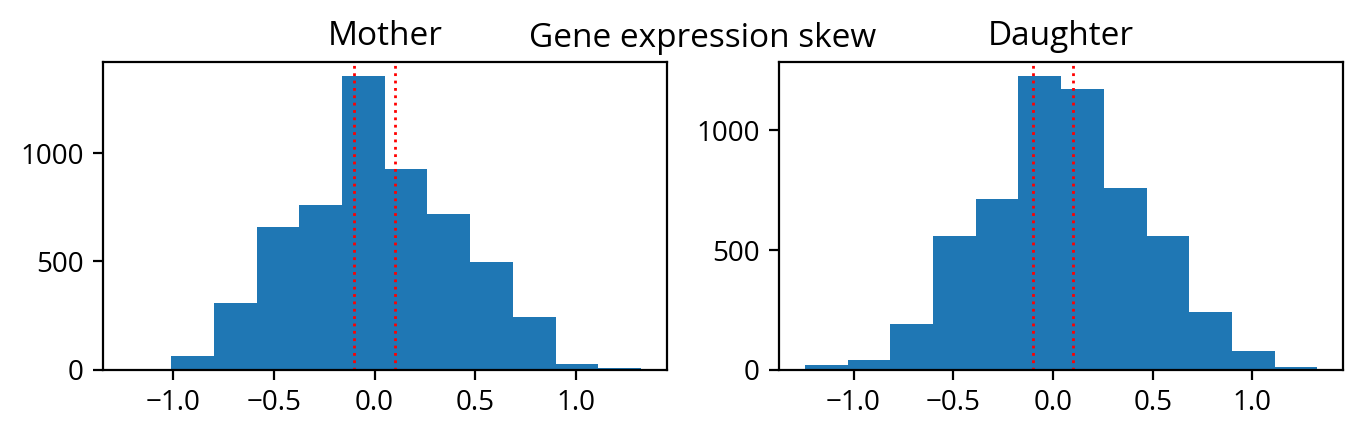

In [931]:
from src.polar_plotter import create_combined_ptr_data_set, plot_skew

skew_threshold = 0.1

qval = 0.95
tx_qval = qval
sm_qval = qval
nuc_qval = qval

expression_combined_polar_data_df, tx_ptr_threshold = create_combined_ptr_data_set(
    analysis.deconvolved_genes_F, config1, tx_qval, eps=1, assign_p_or_t=True,
    skew_threshold=skew_threshold)

plot_skew(expression_combined_polar_data_df, skew_threshold)

In [932]:
expression_combined_polar_data_df.cell_cycle_skew_t.value_counts()

cell_cycle_skew_t
Not cell cycle    5296
trough             126
peak               108
even                42
Name: count, dtype: int64

In [933]:
# Let's try the same for the small fragments data
small_combined_polar_data_df, sm_ptr_threshold = create_combined_ptr_data_set(
    chromatin_analysis.small_promoter_occupancies_df, config1,
    sm_qval, eps=1)

In [934]:
# And the gene body organization
entropies_combined_polar_data_df, entropy_ptr_threshold = create_combined_ptr_data_set(
    chromatin_analysis.nucleosome_genebody_entropies_df, config1,
    qval, eps=1)

In [935]:
# Ensure analysis uses the same ORFs for all analyses, a few genes do not have
# transcription profiles
common_orfs = list(set(expression_combined_polar_data_df.index).intersection(
    set(small_combined_polar_data_df.index)))

expression_combined_polar_data_df = expression_combined_polar_data_df.loc[common_orfs]
small_combined_polar_data_df = small_combined_polar_data_df.loc[common_orfs]

Text(0.5, 1.0, 'Entropy PTR distribution,\nthreshold:1.23 (perc. 95)')

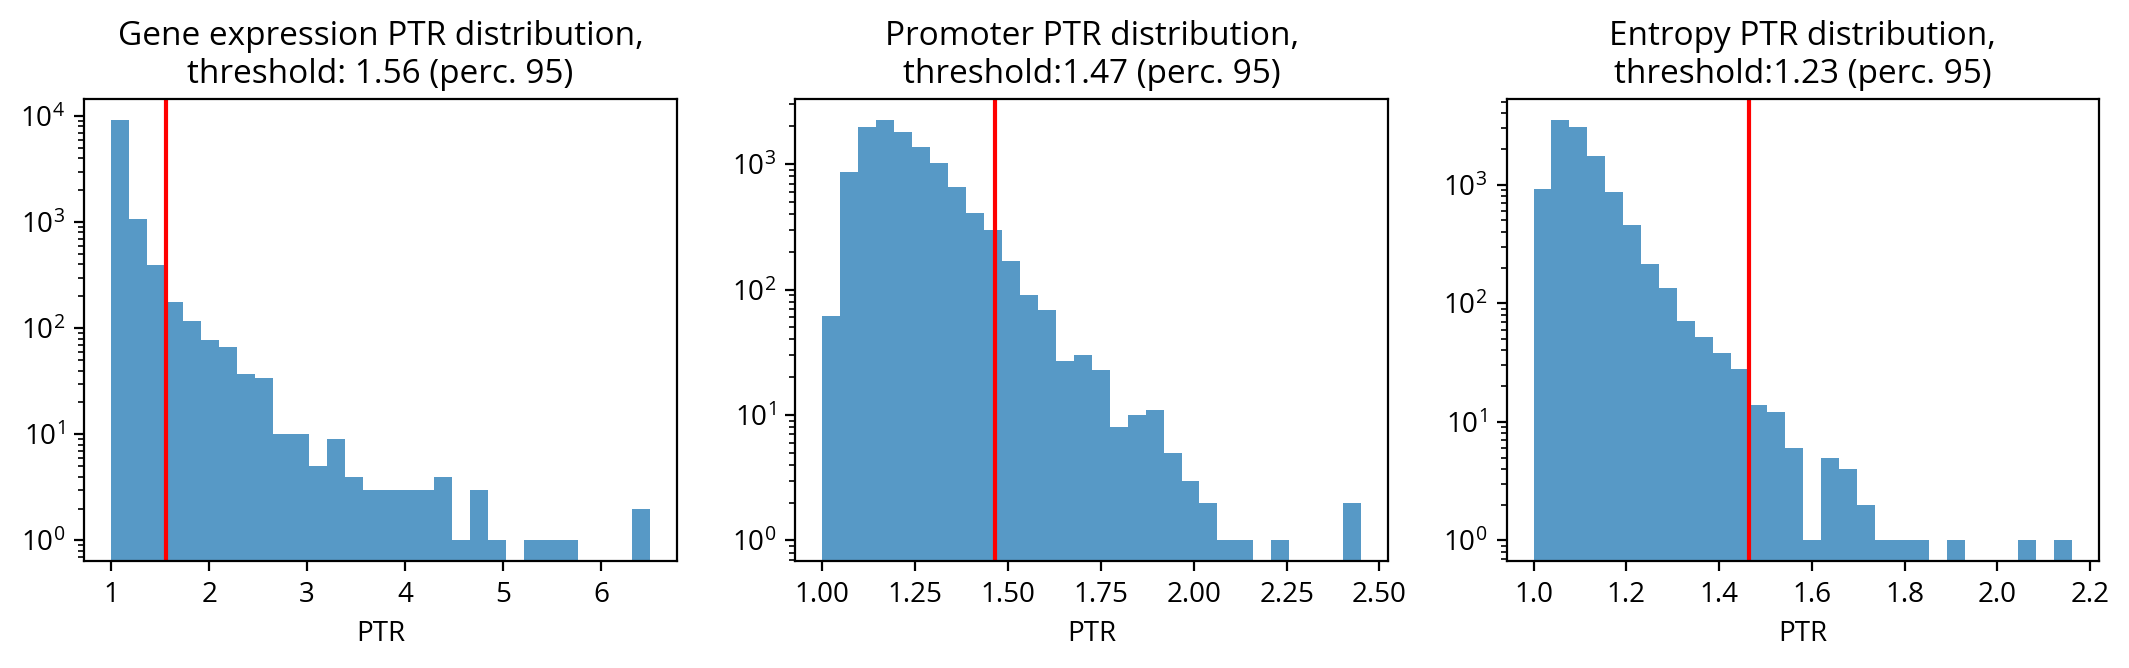

In [936]:

def plot_ptr_hist(expression_combined_polar_data_df, ptr_thresh):
    expression_ptrs = np.concatenate([expression_combined_polar_data_df.ptr_t, 
        expression_combined_polar_data_df.ptr_b])

    plt.hist(expression_ptrs, bins=30, alpha=0.75)
    plt.yscale('log')
    plt.axvline(ptr_thresh, c='red')

    thresholded_genes = expression_ptrs[expression_ptrs > ptr_thresh]
    num_threshold = len(thresholded_genes)
    plt.xlabel('PTR')
    
plt.figure(figsize=(13, 3))
plt.subplot(1, 3, 1)
plot_ptr_hist(expression_combined_polar_data_df, tx_ptr_threshold)
plt.title(f"Gene expression PTR distribution,\nthreshold: {tx_ptr_threshold:.2f} "
          f"(perc. {tx_qval*100:.0f})")
    
plt.subplot(1, 3, 2)
plot_ptr_hist(small_combined_polar_data_df, sm_ptr_threshold)
plt.title(f"Promoter PTR distribution,\nthreshold:{sm_ptr_threshold:.2f} "
          f"(perc. {tx_qval*100:.0f})")

plt.subplot(1, 3, 3)
plot_ptr_hist(entropies_combined_polar_data_df, sm_ptr_threshold)
plt.title(f"Entropy PTR distribution,\nthreshold:{entropy_ptr_threshold:.2f} "
          f"(perc. {tx_qval*100:.0f})")


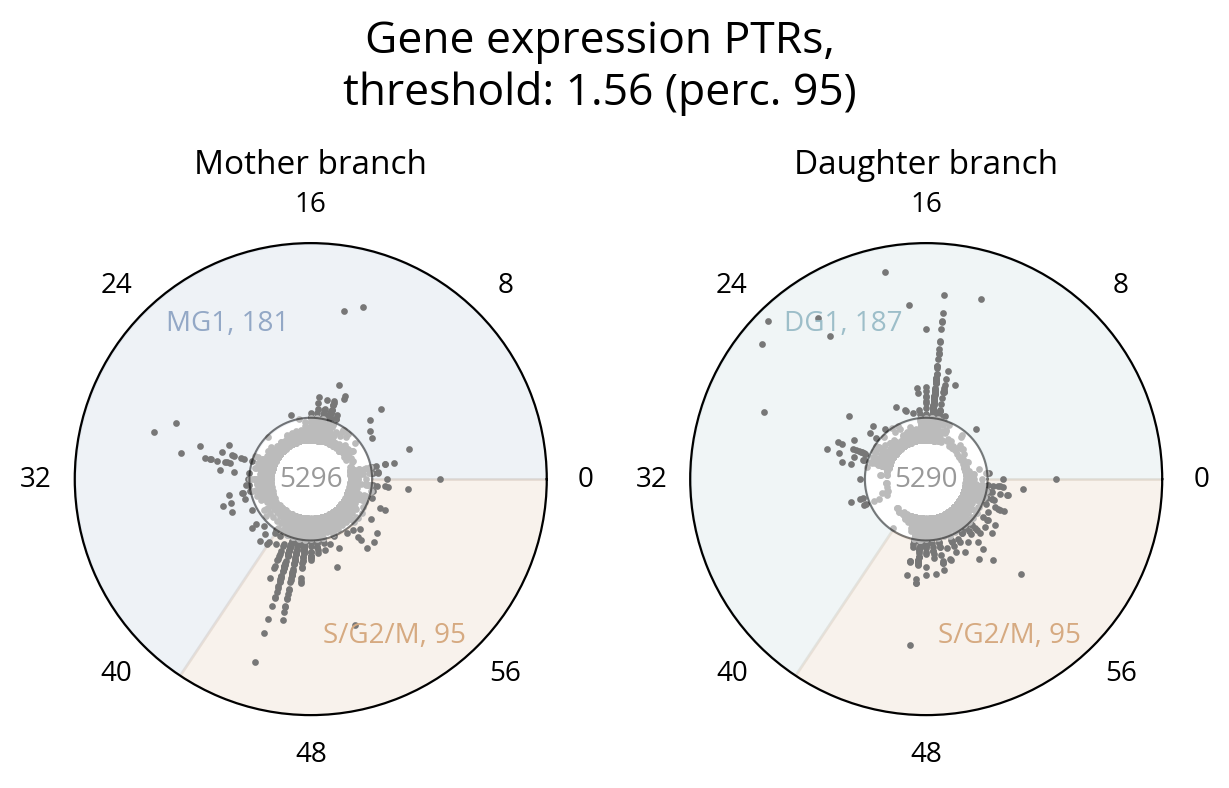

In [1007]:
plot_polar_branches_data(expression_combined_polar_data_df,
                        tx_ptr_threshold, tx_qval, "Gene expression", (0, 6),
                        plot_skew_cat=False)

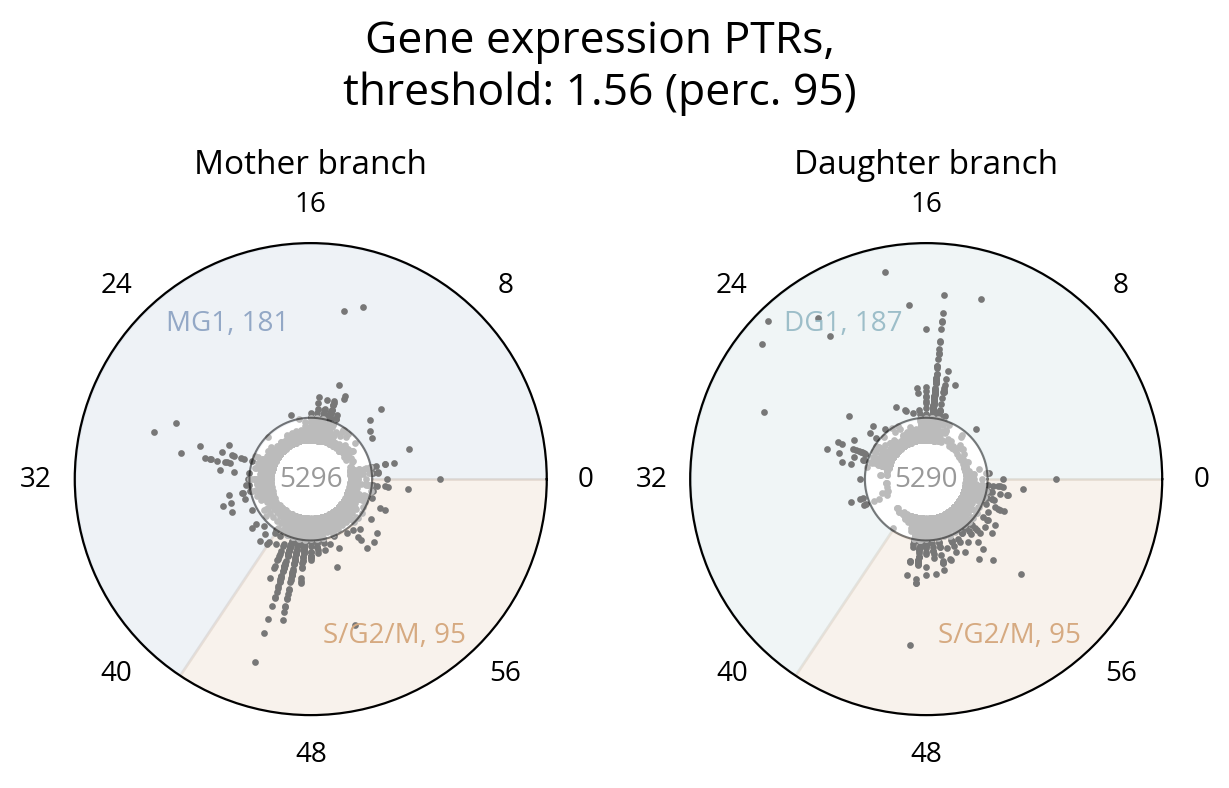

In [1013]:
from src.polar_plotter import PolarPlot, plot_polar_branches_data

plot_polar_branches_data(expression_combined_polar_data_df,
                        tx_ptr_threshold, tx_qval, "Gene expression", (0, 6),
                        plot_skew_cat=False)


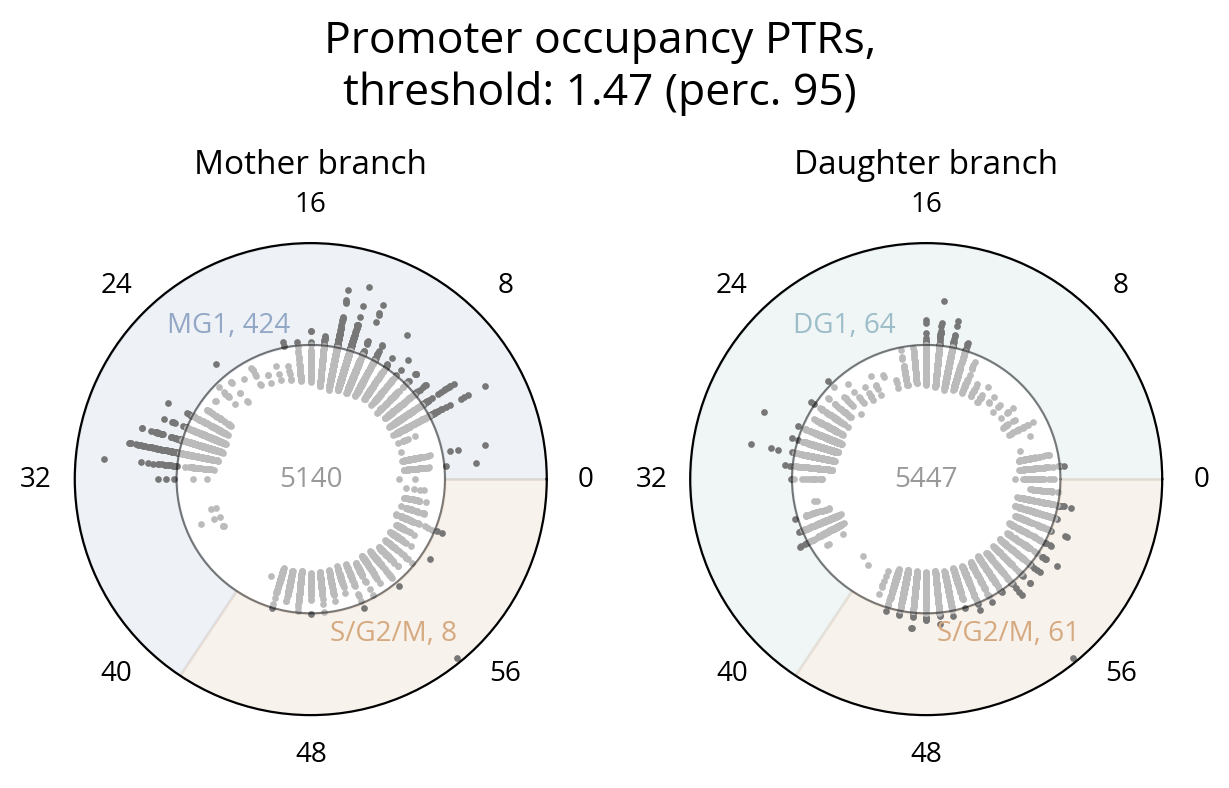

In [1012]:
plot_polar_branches_data(small_combined_polar_data_df,
                        sm_ptr_threshold, sm_qval, "Promoter occupancy", (0.1, 2.5))

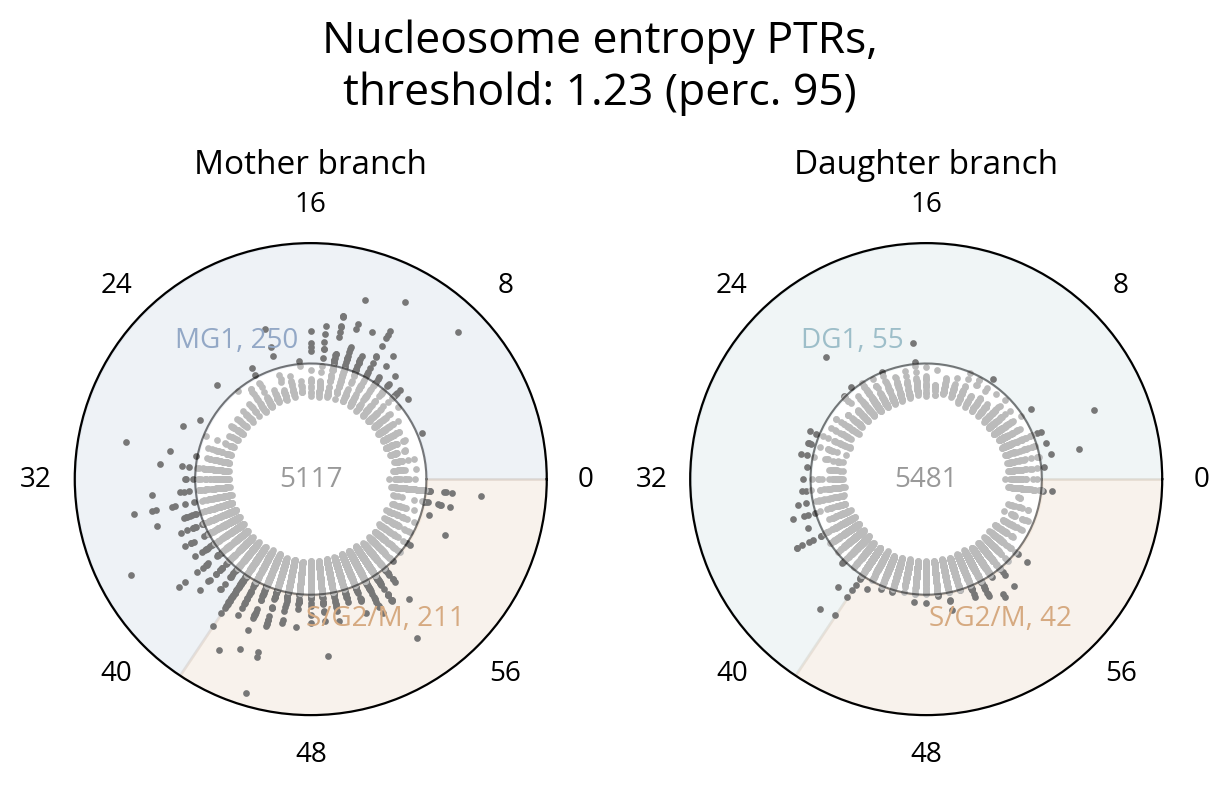

In [939]:
plot_polar_branches_data(entropies_combined_polar_data_df,
                        entropy_ptr_threshold, sm_qval, "Nucleosome entropy", (0.5, 2))

In [940]:
from src.expression_chromatin_analysis_plots import categorize_genes

# Promoter commonality
t_merged_df, t_promoter_category_counts = categorize_genes(expression_combined_polar_data_df, 
    small_combined_polar_data_df, suffix='_t',
    cat_1_name='expression_only', cat_2_name='promoter_only')
b_merged_df, b_promoter_category_counts = categorize_genes(expression_combined_polar_data_df, 
    small_combined_polar_data_df, suffix='_b',
    cat_1_name='expression_only', cat_2_name='promoter_only')

In [941]:
# Entropy commonality
t_merged_df, t_entropy_category_counts = categorize_genes(expression_combined_polar_data_df, 
    entropies_combined_polar_data_df, suffix='_t',
    cat_1_name='expression_only', cat_2_name='entropy_only')
b_merged_df, b_entropy_category_counts = categorize_genes(expression_combined_polar_data_df, 
    entropies_combined_polar_data_df, suffix='_b',
    cat_1_name='expression_only', cat_2_name='entropy_only')

In [942]:
# Let's examine the commonality between the chromatin metrics
t_chrom_merged_df, t_chrom_category_counts = categorize_genes(entropies_combined_polar_data_df, 
    small_combined_polar_data_df, suffix='_t',
    cat_1_name='entropy_only', cat_2_name='promoter_only')

b_chrom_merged_df, b_chrom_category_counts = categorize_genes(entropies_combined_polar_data_df, 
    small_combined_polar_data_df, suffix='_b',
    cat_1_name='entropy_only', cat_2_name='promoter_only')

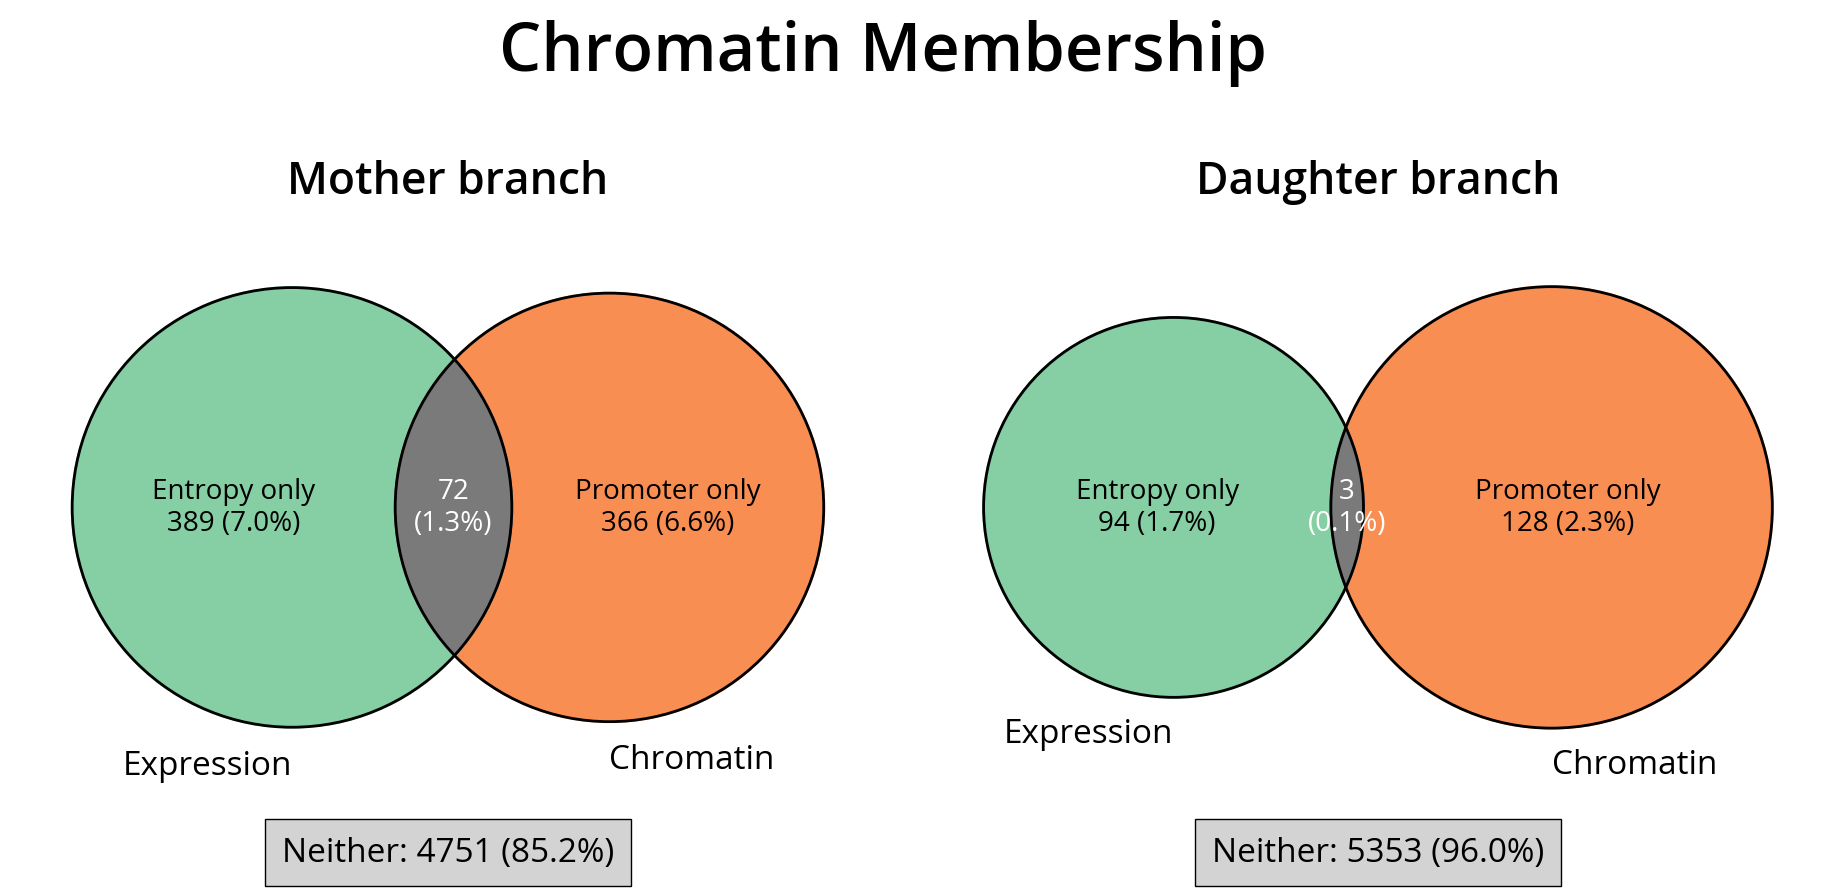

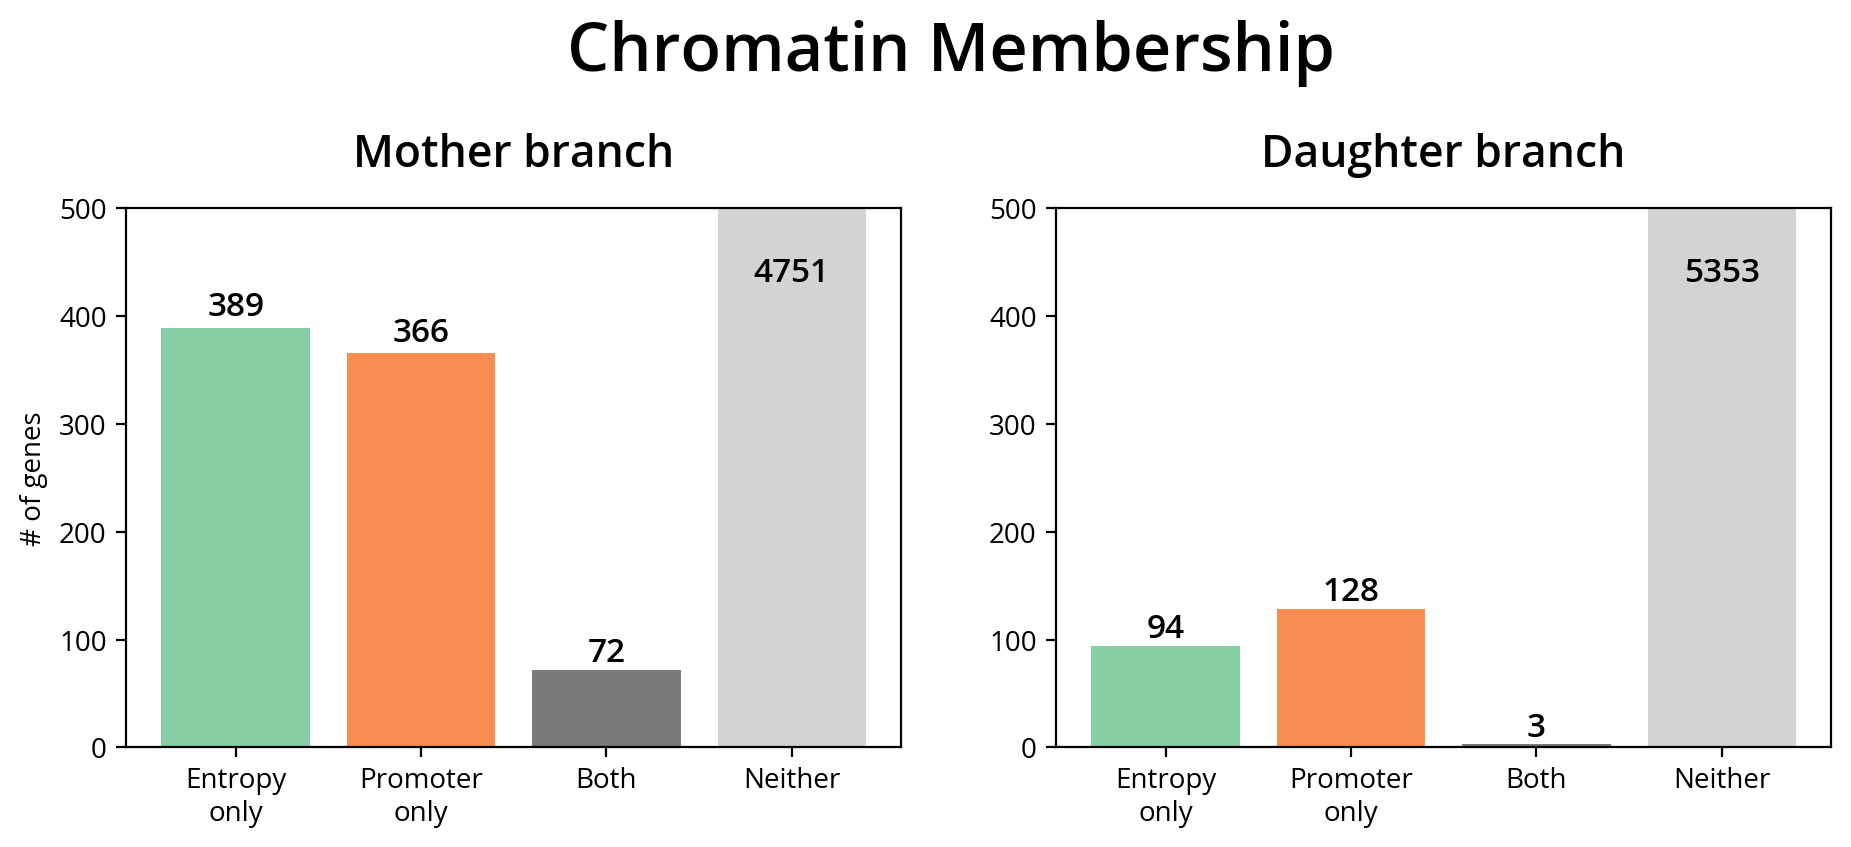

In [943]:
from src.expression_chromatin_analysis_plots import plot_category_counts, plot_category_venn_diagram

plot_category_venn_diagram(t_chrom_category_counts, b_chrom_category_counts,
                    category_keys=['entropy_only', 'promoter_only', 'both', 'neither'],
                    category_names=["Entropy\nonly", "Promoter\nonly",
                                   "Both", "Neither"],
                    title="Chromatin Membership")

plot_category_counts(t_chrom_category_counts, b_chrom_category_counts,
                    category_keys=['entropy_only', 'promoter_only', 'both', 'neither'],
                    category_names=["Entropy\nonly", "Promoter\nonly",
                                   "Both", "Neither"],
                    title="Chromatin Membership")

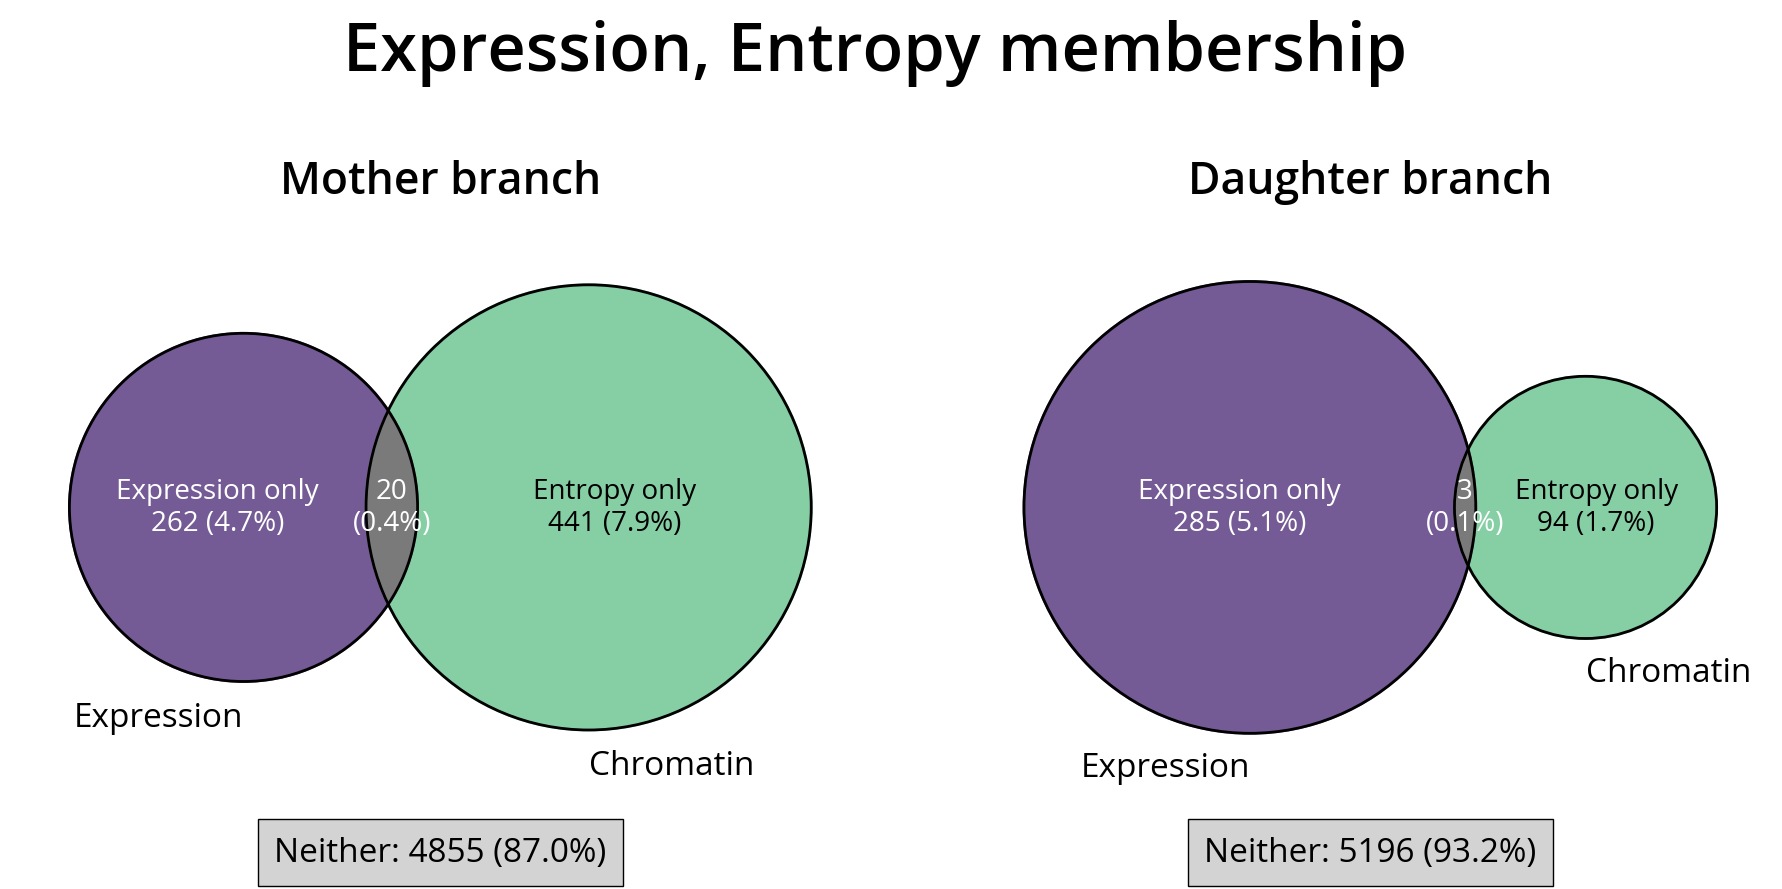

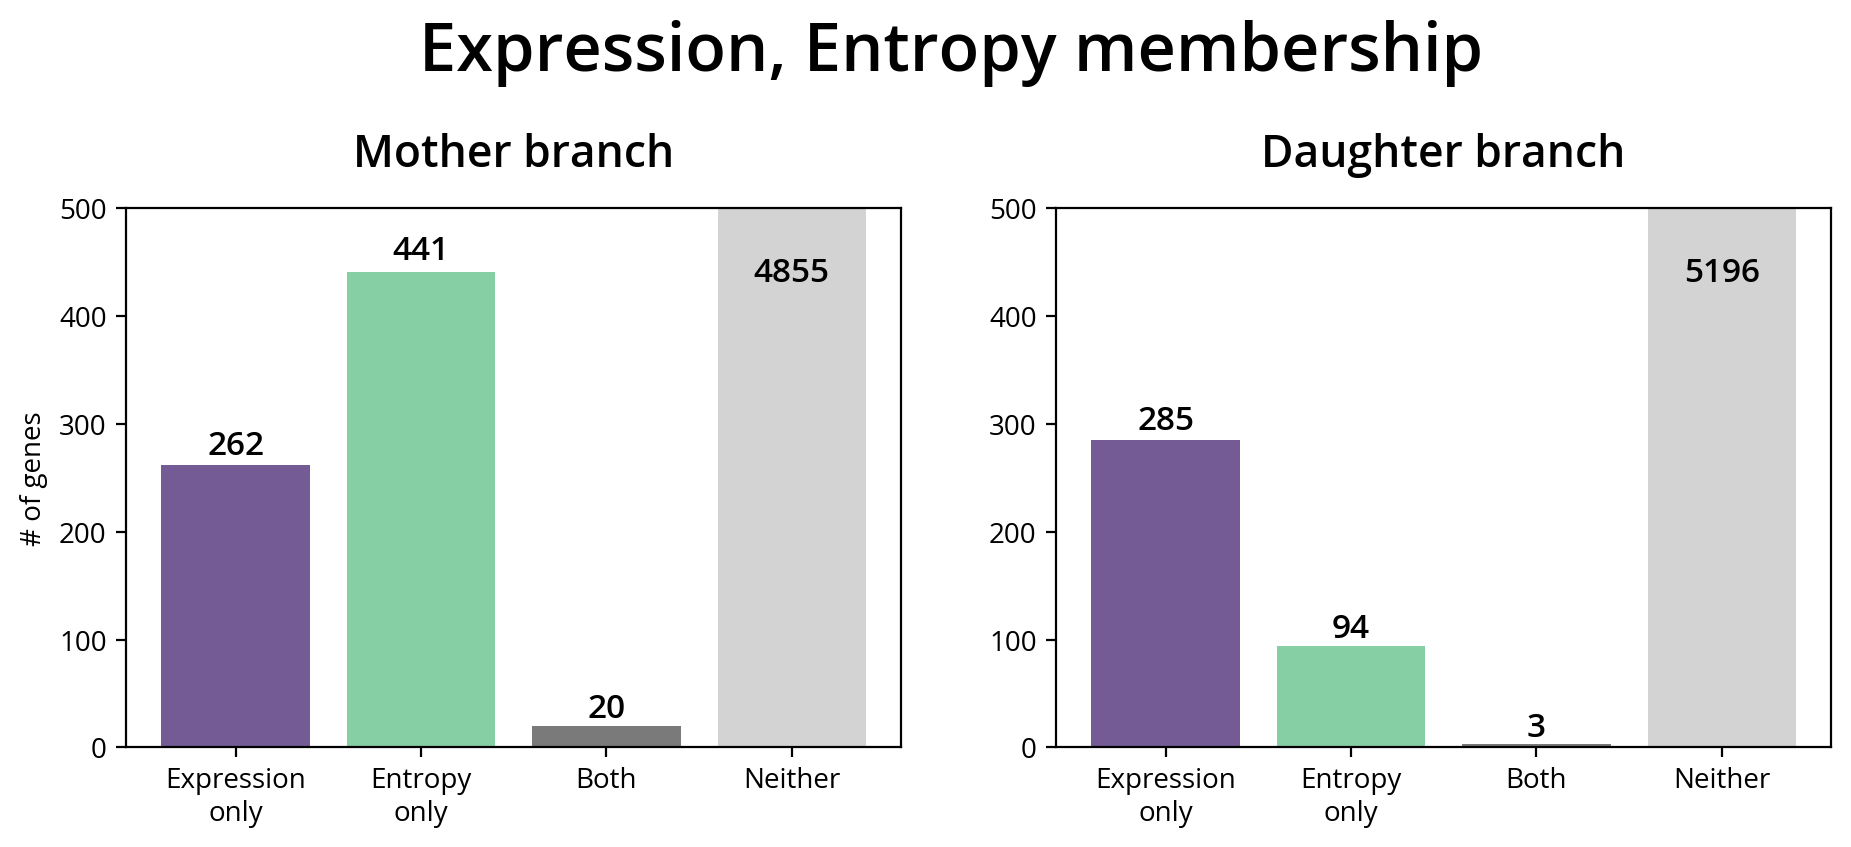

In [944]:

plot_category_venn_diagram(t_entropy_category_counts, b_entropy_category_counts,
                    category_keys=['expression_only', 'entropy_only', 'both', 'neither'],
                    category_names=["Expression\nonly", "Entropy\nonly",
                                   "Both", "Neither"],
                    title="Expression, Entropy membership")

plot_category_counts(t_entropy_category_counts, b_entropy_category_counts,
                    category_keys=['expression_only', 'entropy_only', 'both', 'neither'],
                    category_names=["Expression\nonly", "Entropy\nonly",
                                   "Both", "Neither"],
                    title="Expression, Entropy membership")

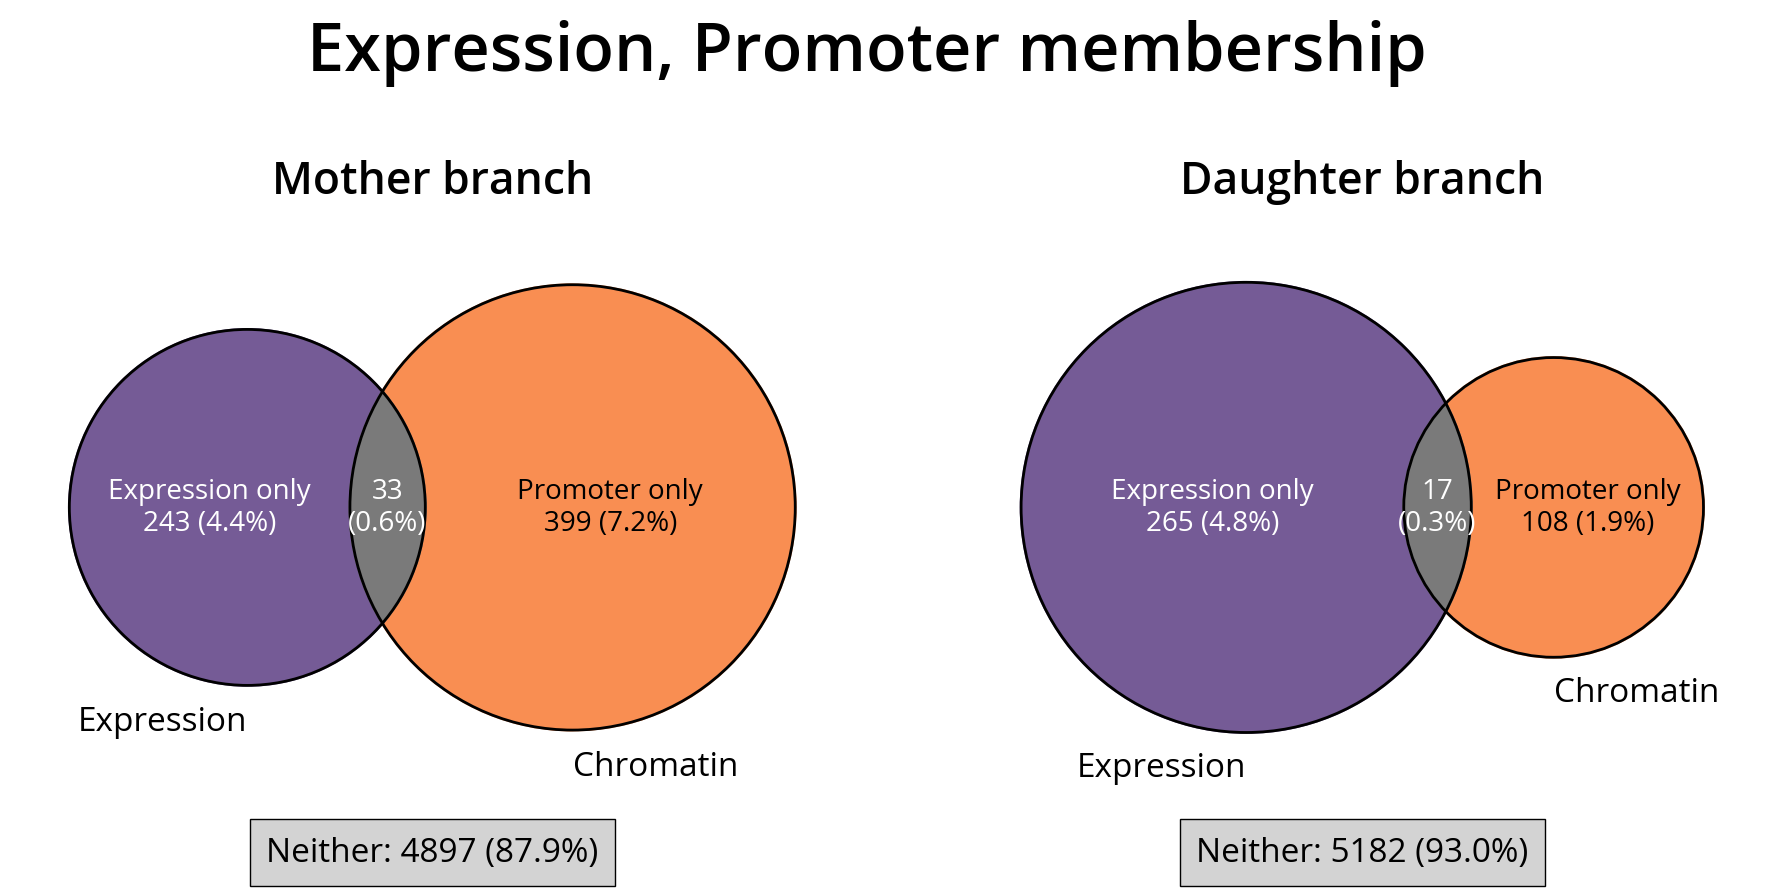

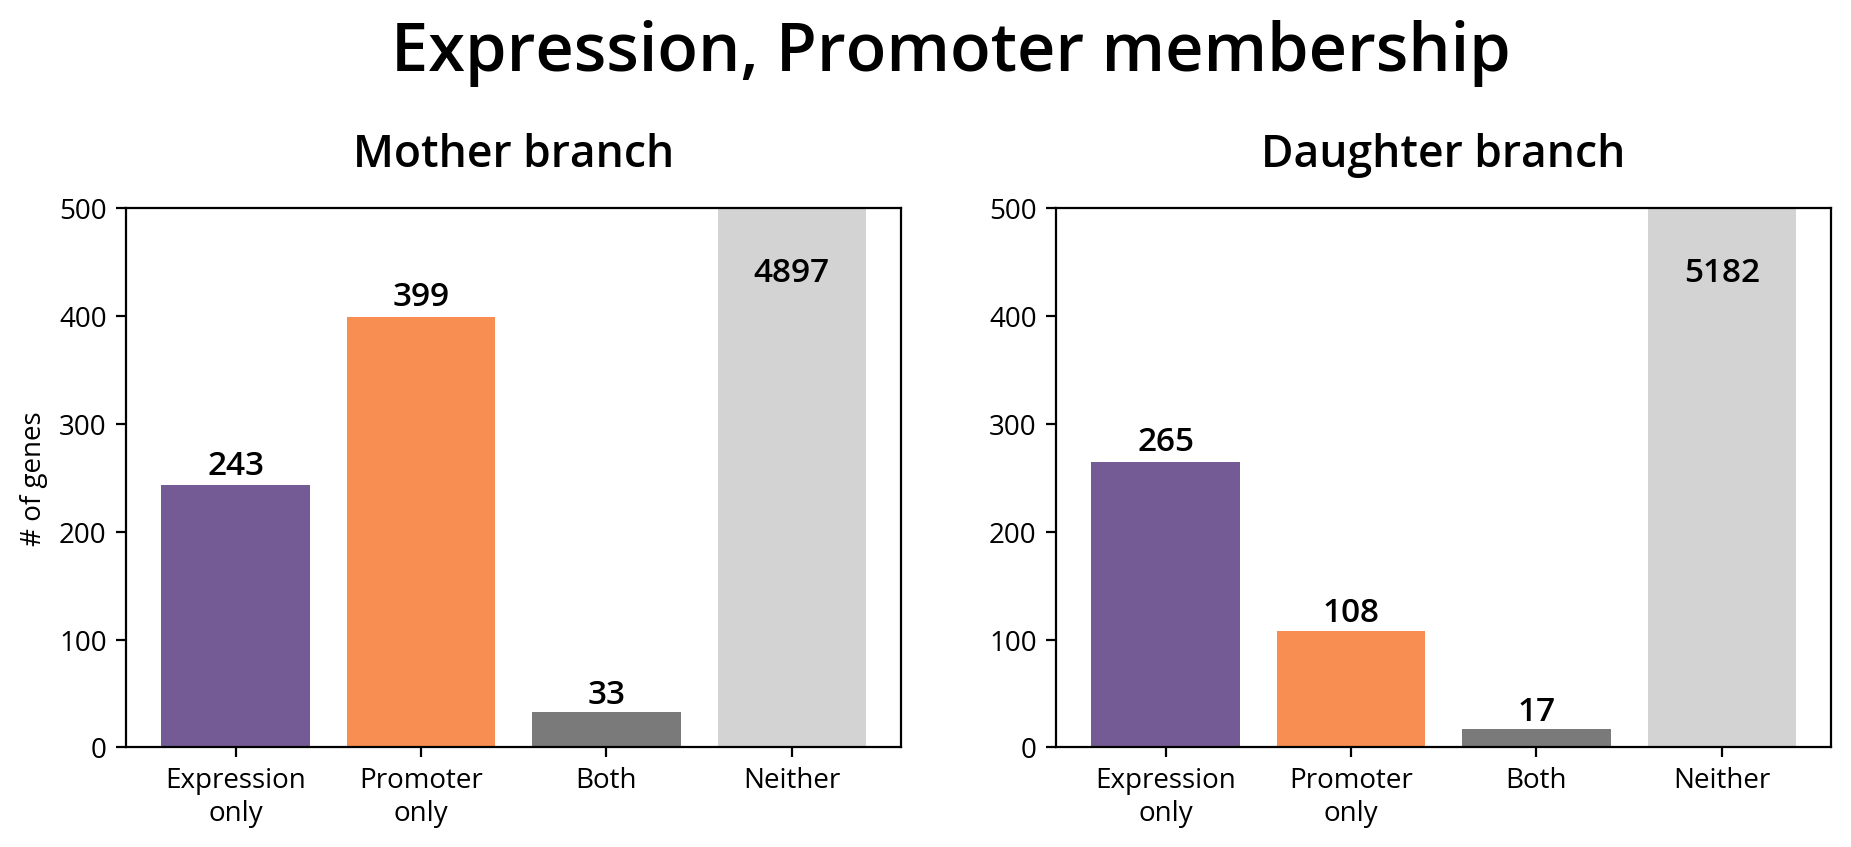

In [945]:

plot_category_venn_diagram(t_promoter_category_counts, b_promoter_category_counts,
                    category_keys=['expression_only', 'promoter_only', 'both', 'neither'],
                    category_names=["Expression\nonly", "Promoter\nonly",
                                   "Both", "Neither"],
                    title="Expression, Promoter membership")

plot_category_counts(t_promoter_category_counts, b_promoter_category_counts,
                    category_keys=['expression_only', 'promoter_only', 'both', 'neither'],
                    category_names=["Expression\nonly", "Promoter\nonly",
                                   "Both", "Neither"],
                    title="Expression, Promoter membership")

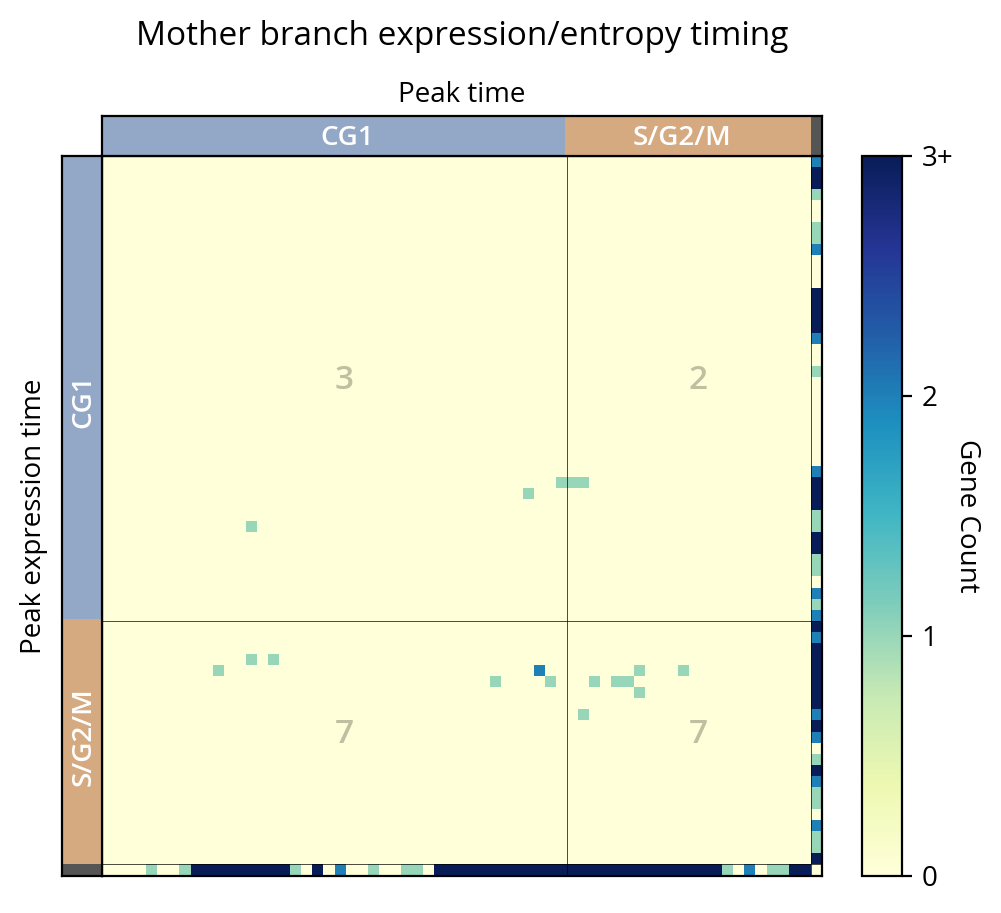

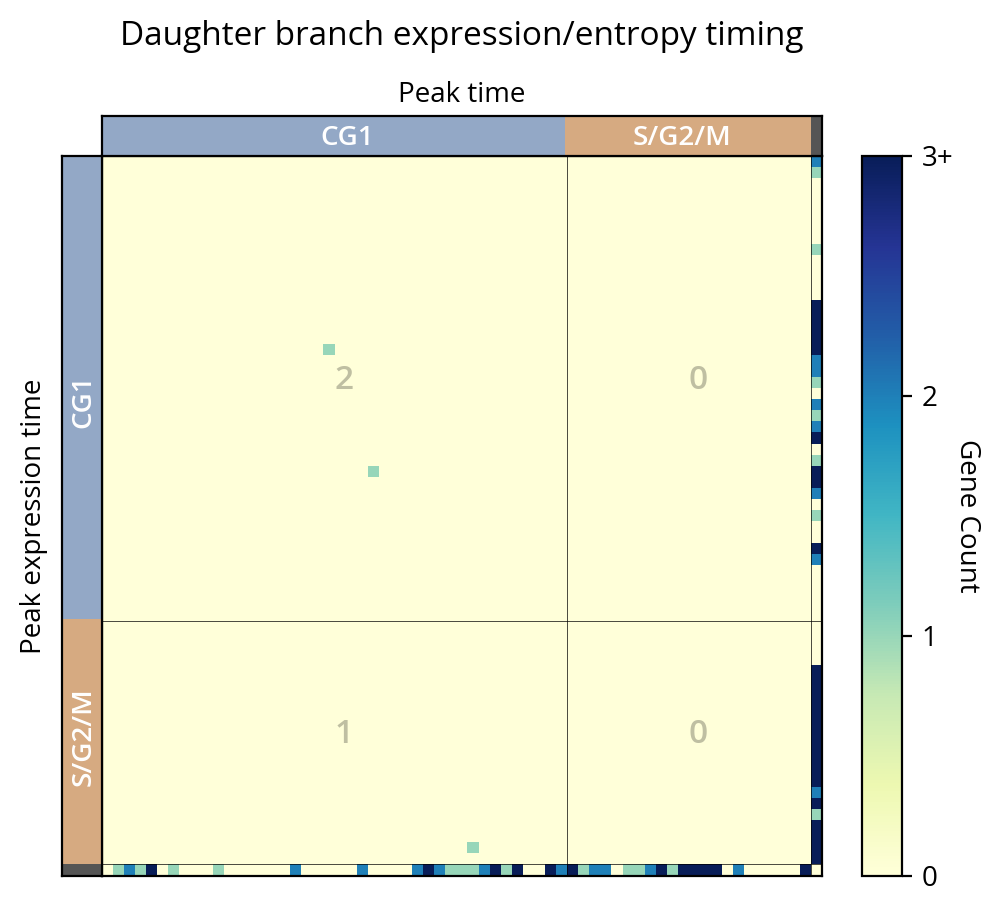

In [946]:
from src.heatmap_counts import plot_cooccurences

_, d_joined_counts_data, _ = plot_cooccurences(expression_combined_polar_data_df, 
    entropies_combined_polar_data_df, branch='mother', metric='entropy')
_, d_joined_counts_data, _ = plot_cooccurences(expression_combined_polar_data_df, 
    entropies_combined_polar_data_df, branch='daughter', metric='entropy')


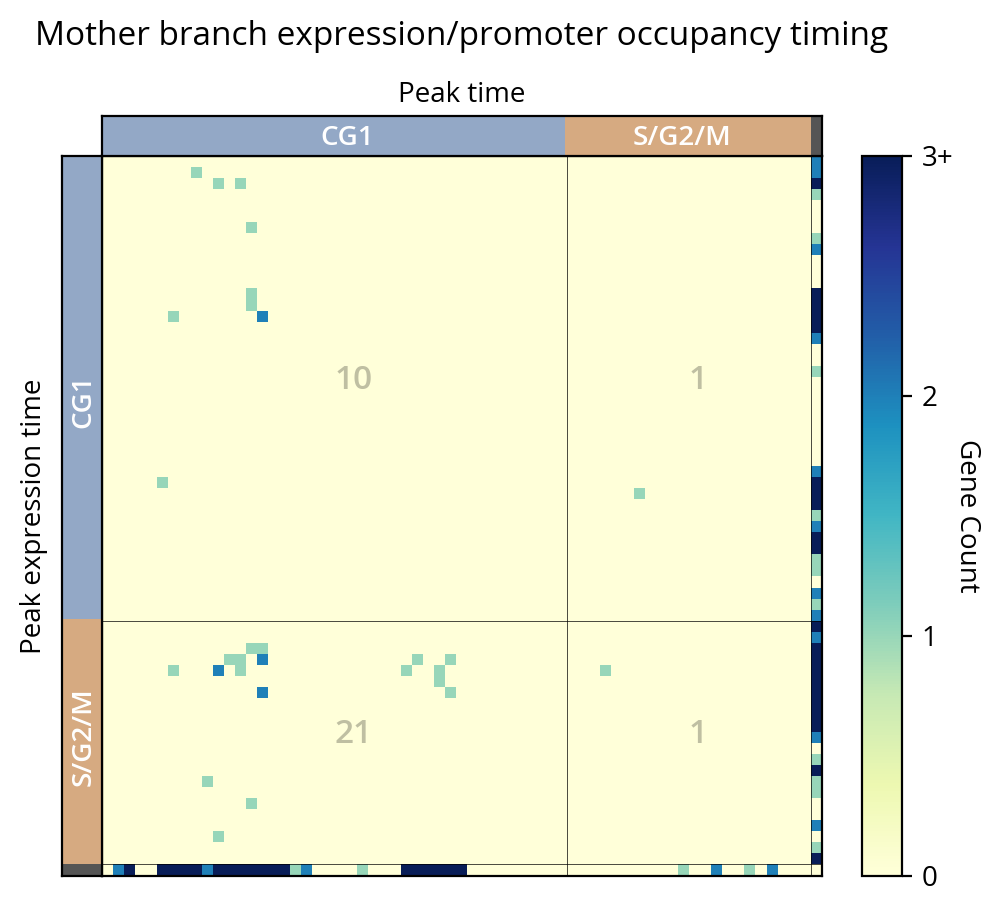

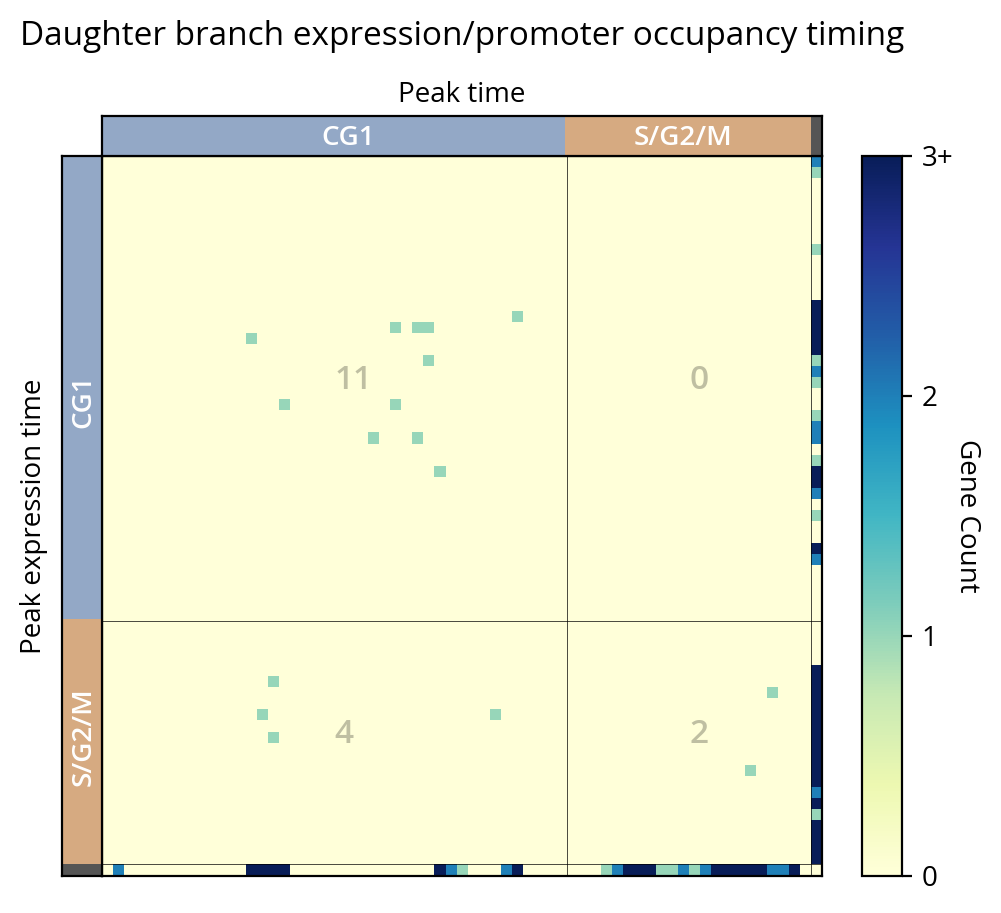

In [947]:
from src.heatmap_counts import plot_cooccurences

_, d_joined_counts_data, _ = plot_cooccurences(expression_combined_polar_data_df, 
    small_combined_polar_data_df, branch='mother', metric='promoter occupancy')

_, d_joined_counts_data, _ = plot_cooccurences(expression_combined_polar_data_df, 
    small_combined_polar_data_df, branch='daughter', metric='promoter occupancy')

Text(0.5, 1.03, 'Daughter branch')

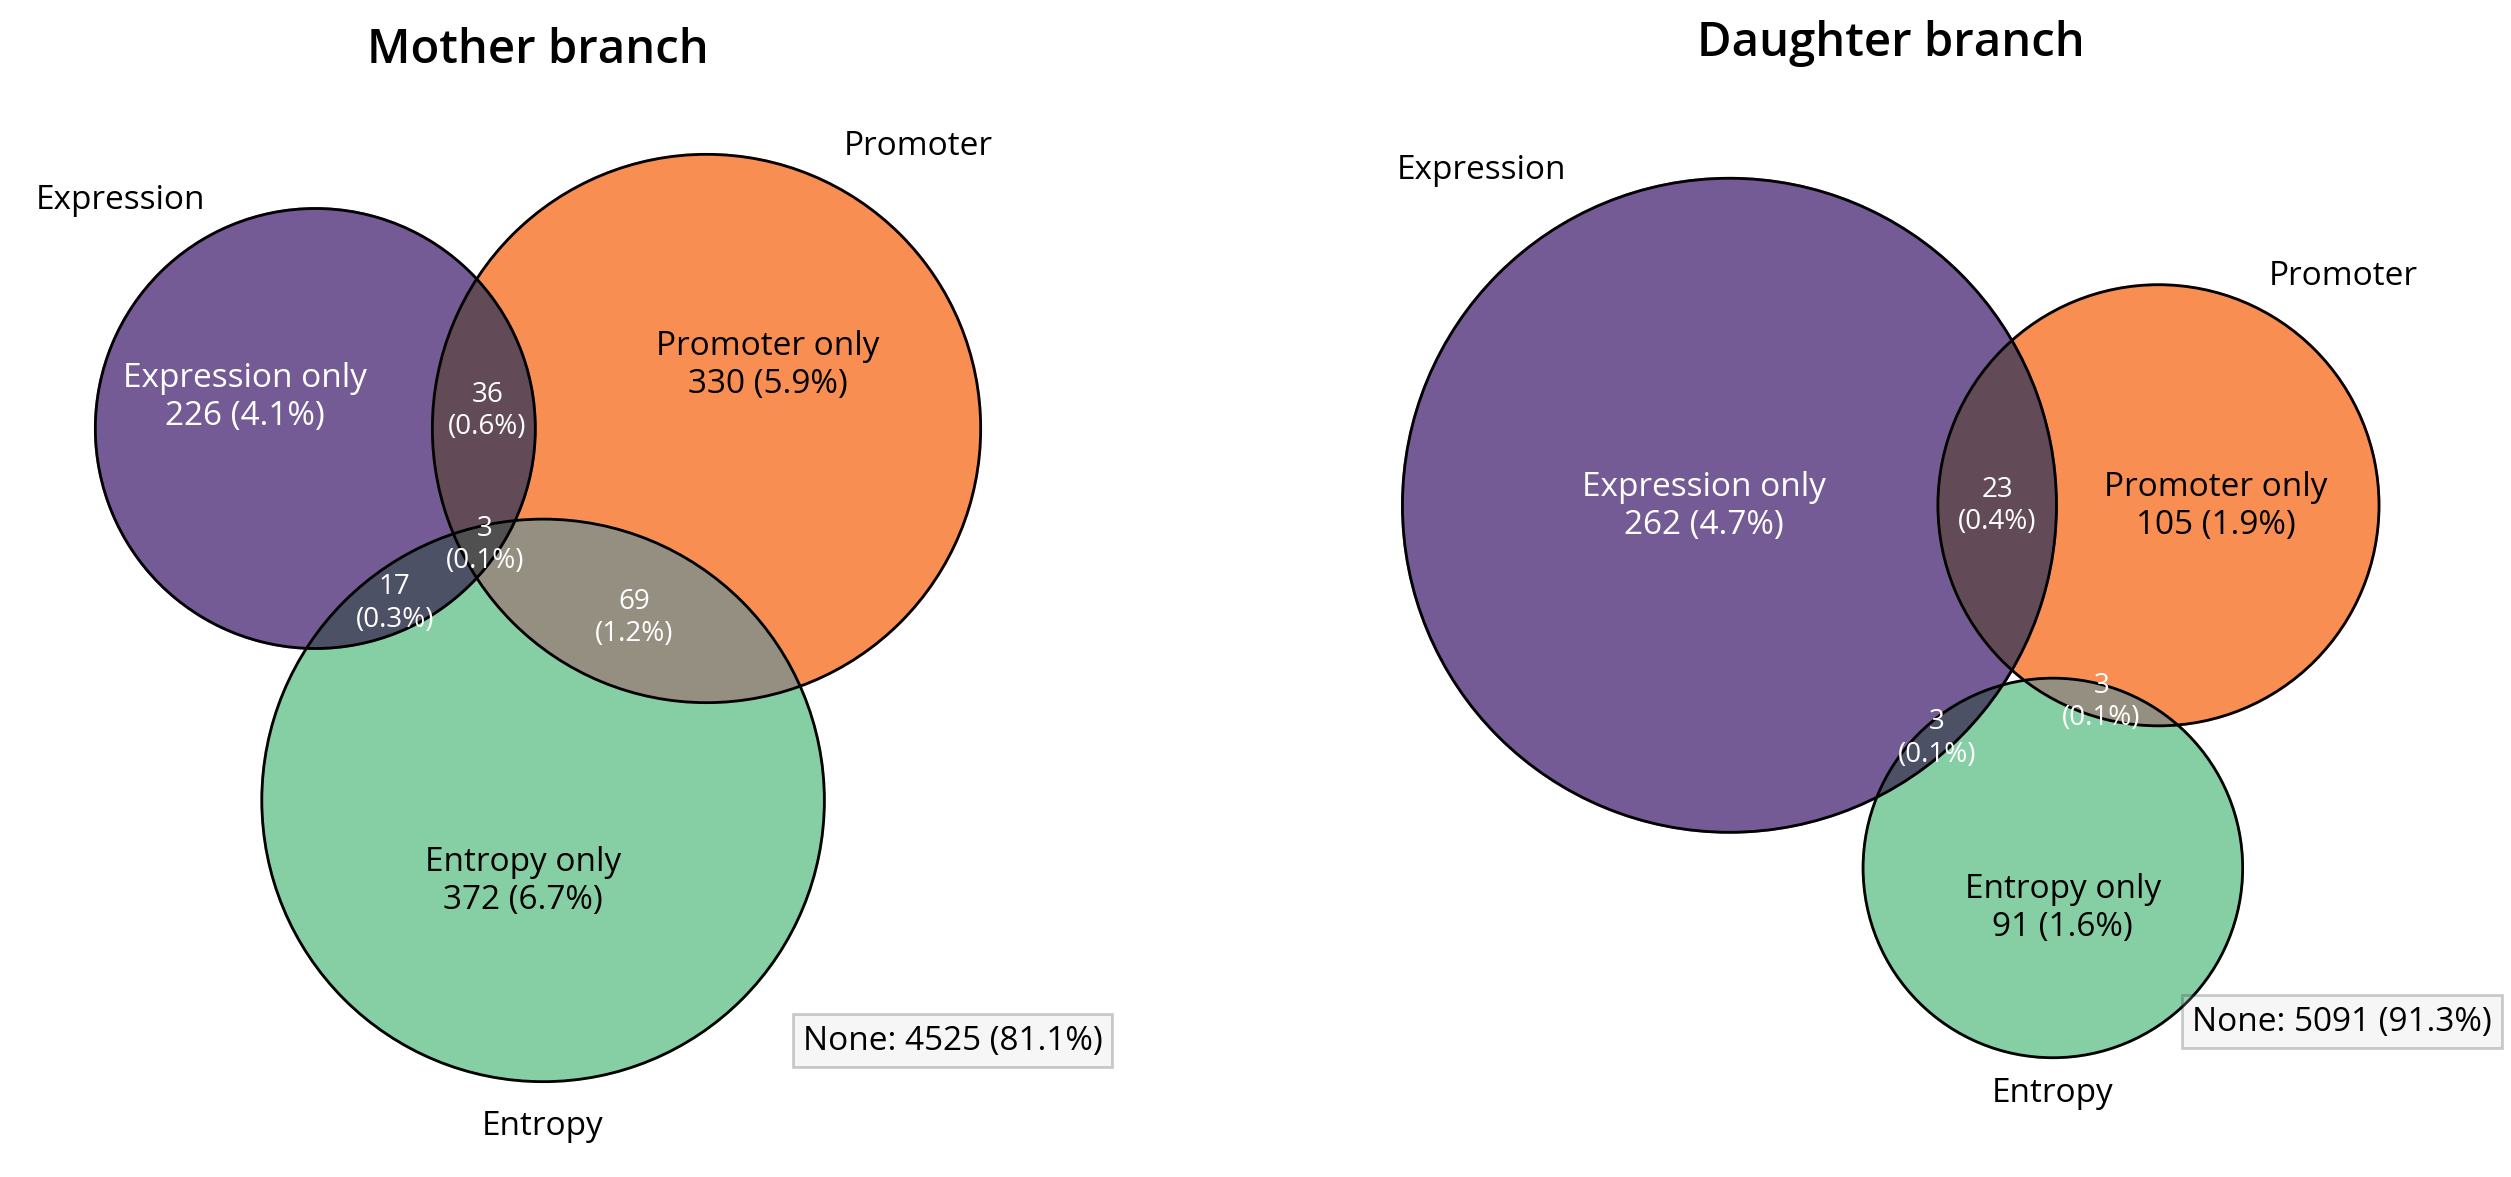

In [948]:
from src.expression_chromatin_analysis_plots import categorize_genes3
from src.expression_chromatin_analysis_plots import plot_three_category_venn_diagram

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 7))

cat3_merged_df, cat3_categories = categorize_genes3(expression_combined_polar_data_df,
                 small_combined_polar_data_df,
                 entropies_combined_polar_data_df, suffix='_t')
plot_three_category_venn_diagram(ax0, cat3_categories)
ax0.set_title("Mother branch", fontsize=17, fontweight='demi', y=1)

cat3_merged_df, cat3_categories = categorize_genes3(expression_combined_polar_data_df,
                 small_combined_polar_data_df,
                 entropies_combined_polar_data_df, suffix='_b')
plot_three_category_venn_diagram(ax1, cat3_categories)
ax1.set_title("Daughter branch", fontsize=17, fontweight='demi', y=1.03)

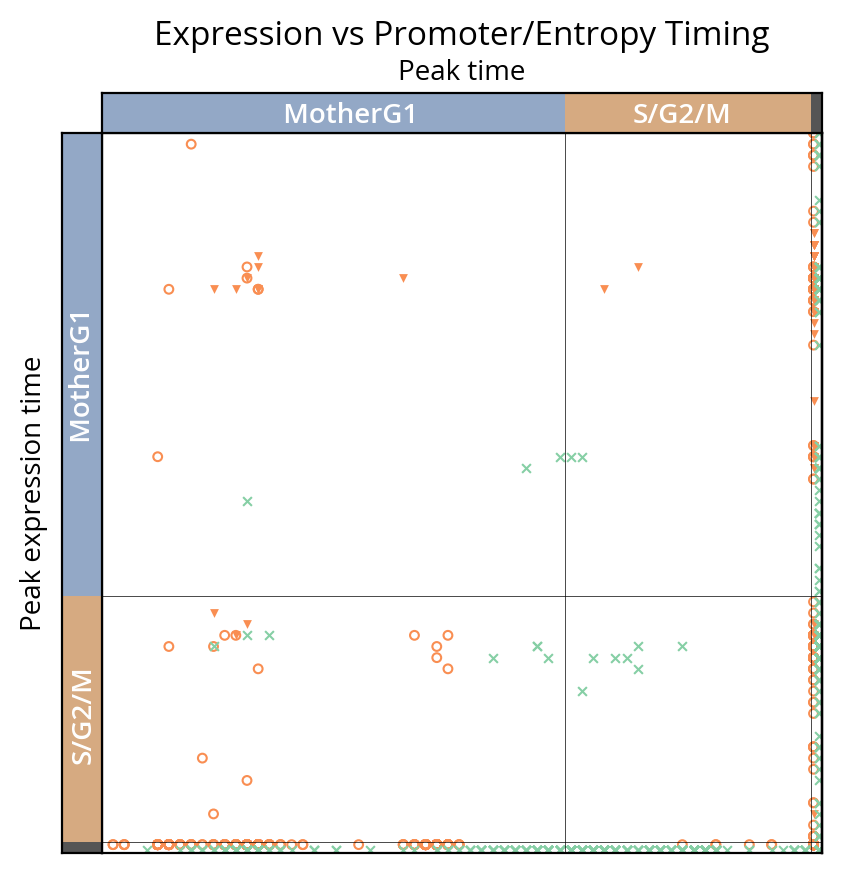

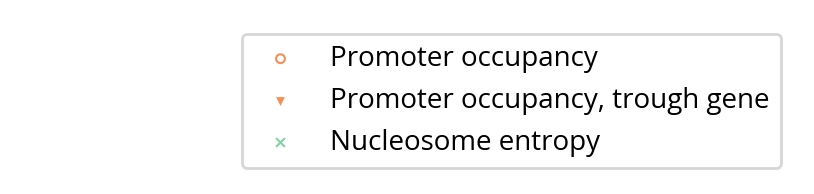

In [1018]:
from src.heatmap_counts import create_subplot_grid, annotate_top_ax, annotate_left_ax

from src.expression_chromatin_analysis_plots import plot_scatter_timing

fig, axs = create_subplot_grid(cbar_ax=False)
ax = axs['main']
prom_scatter, prom_trough_scatter, entr_scatter = plot_scatter_timing(ax, expression_combined_polar_data_df, 
                    small_combined_polar_data_df, 
    entropies_combined_polar_data_df,
                   suffix='_t', plot_trough_indices=True)
ax.set_title('Expression vs Promoter/Entropy Timing', y=1.1)

annotate_top_ax(axs['top'], g1_key='MG1')
annotate_left_ax(axs['left'], g1_key='MG1')

import matplotlib.legend as mlegend

plt.figure(figsize=(5, 1))
ax = plt.gca()
legend = mlegend.Legend(ax, [prom_scatter, prom_trough_scatter, entr_scatter], 
    ['Promoter occupancy', 
     'Promoter occupancy, trough gene',
    'Nucleosome entropy'])
ax.add_artist(legend)
from src.plot_helpers import hide_spines
hide_spines(ax)

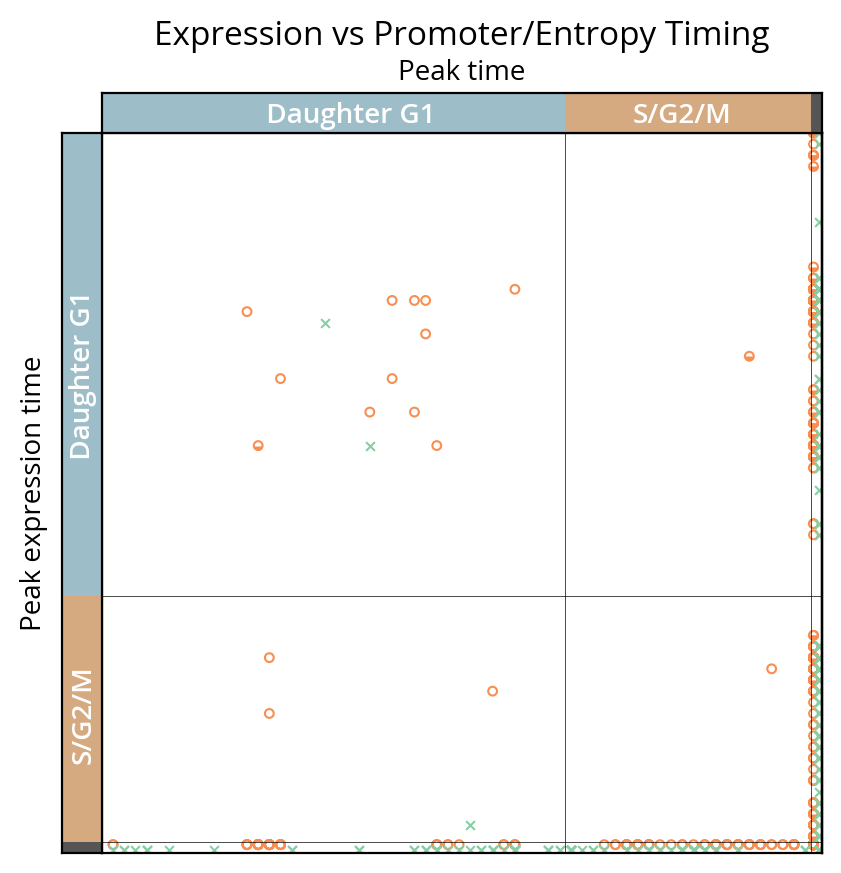

In [1002]:
fig, axs = create_subplot_grid(cbar_ax=False)
ax = axs['main']
plot_scatter_timing(ax, expression_combined_polar_data_df, 
                    small_combined_polar_data_df, entropies_combined_polar_data_df,
                   suffix='_b', plot_trough_indices=True)
ax.set_title('Expression vs Promoter/Entropy Timing', y=1.1)

annotate_top_ax(axs['top'], g1_key='DG1')
annotate_left_ax(axs['left'], g1_key='DG1')
#ax.legend(fontsize=8, loc='upper right')

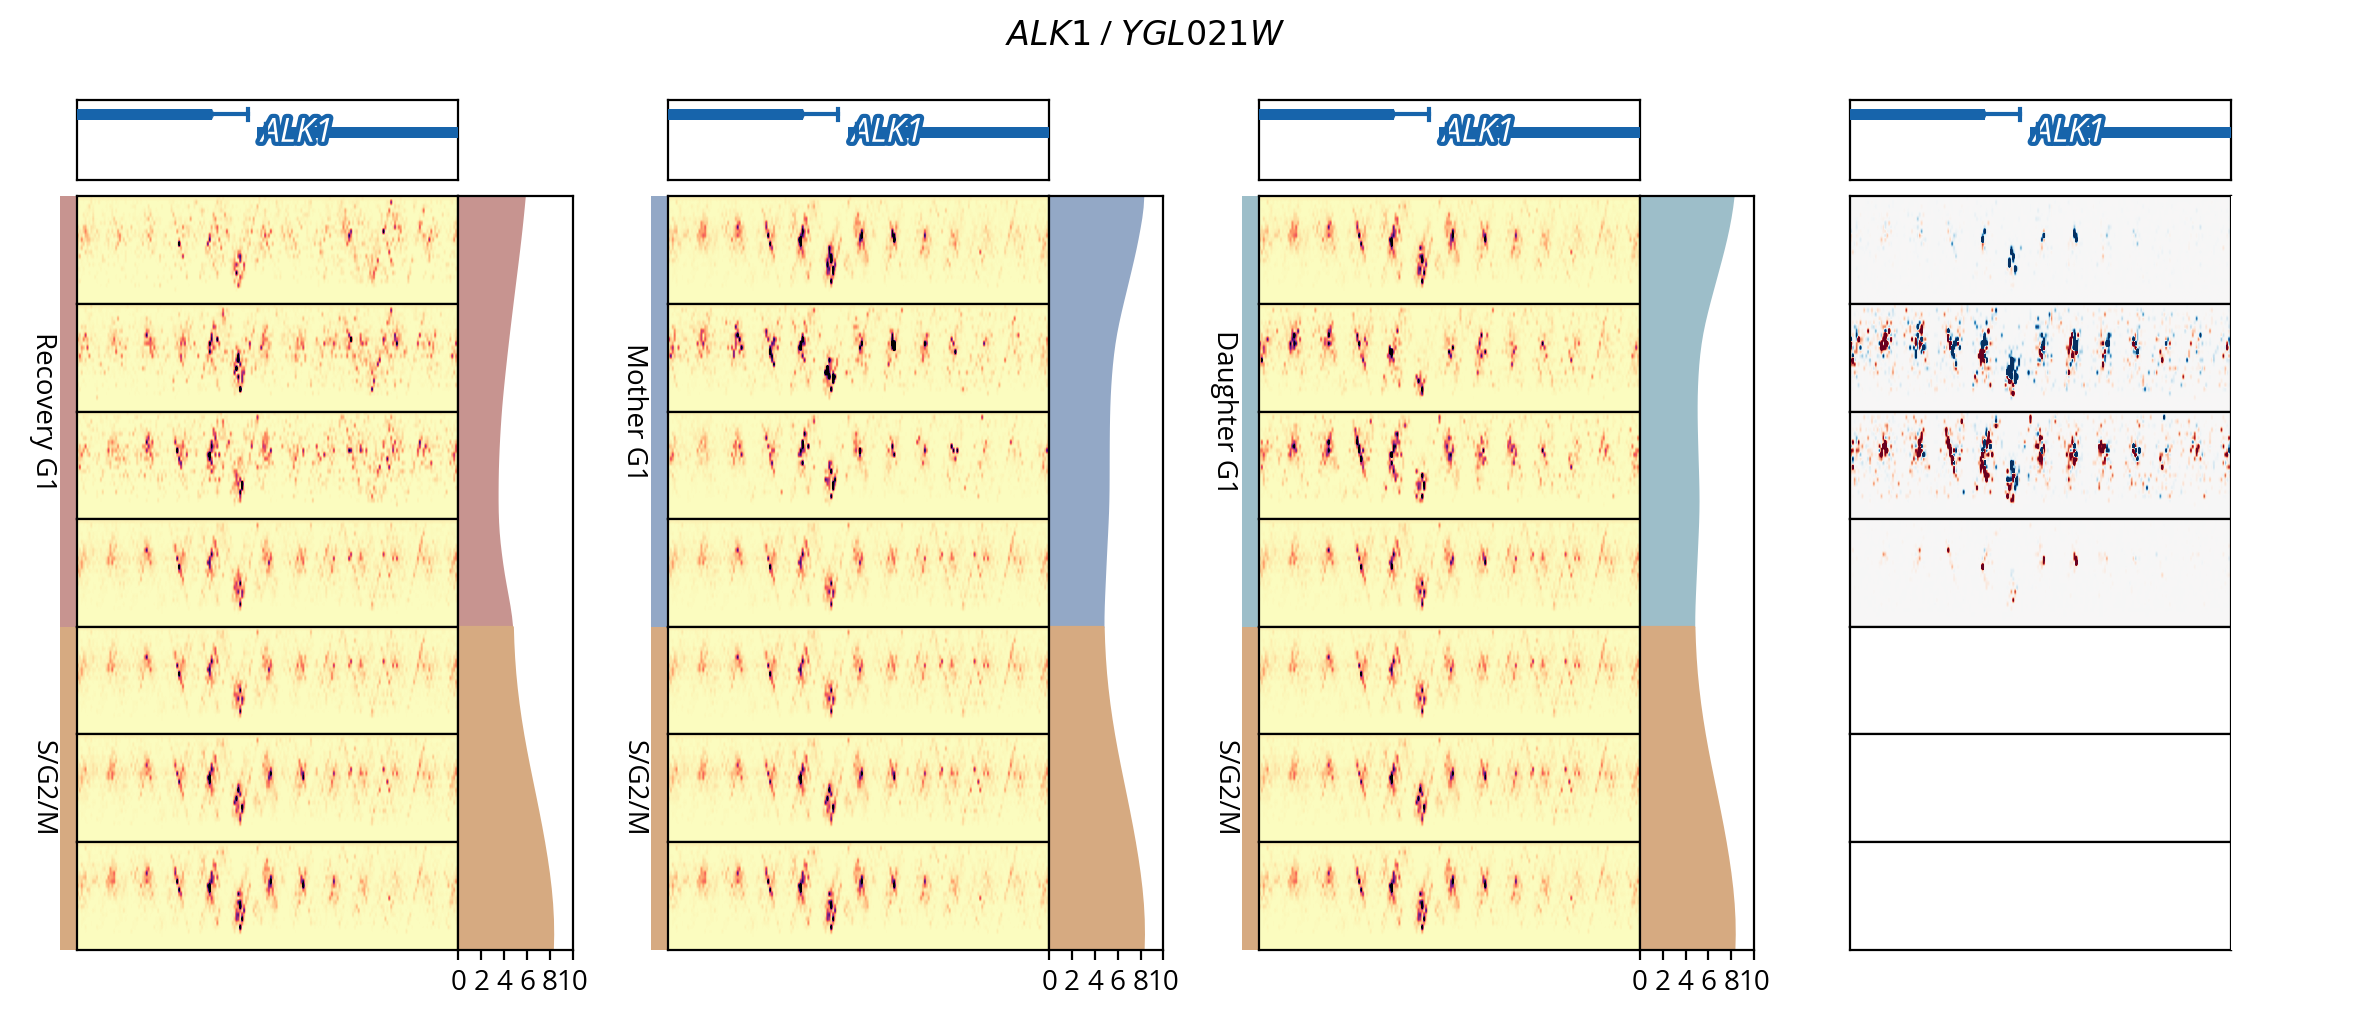

In [951]:
genome_analysis.plot_gene('ALK1', config1, analysis)

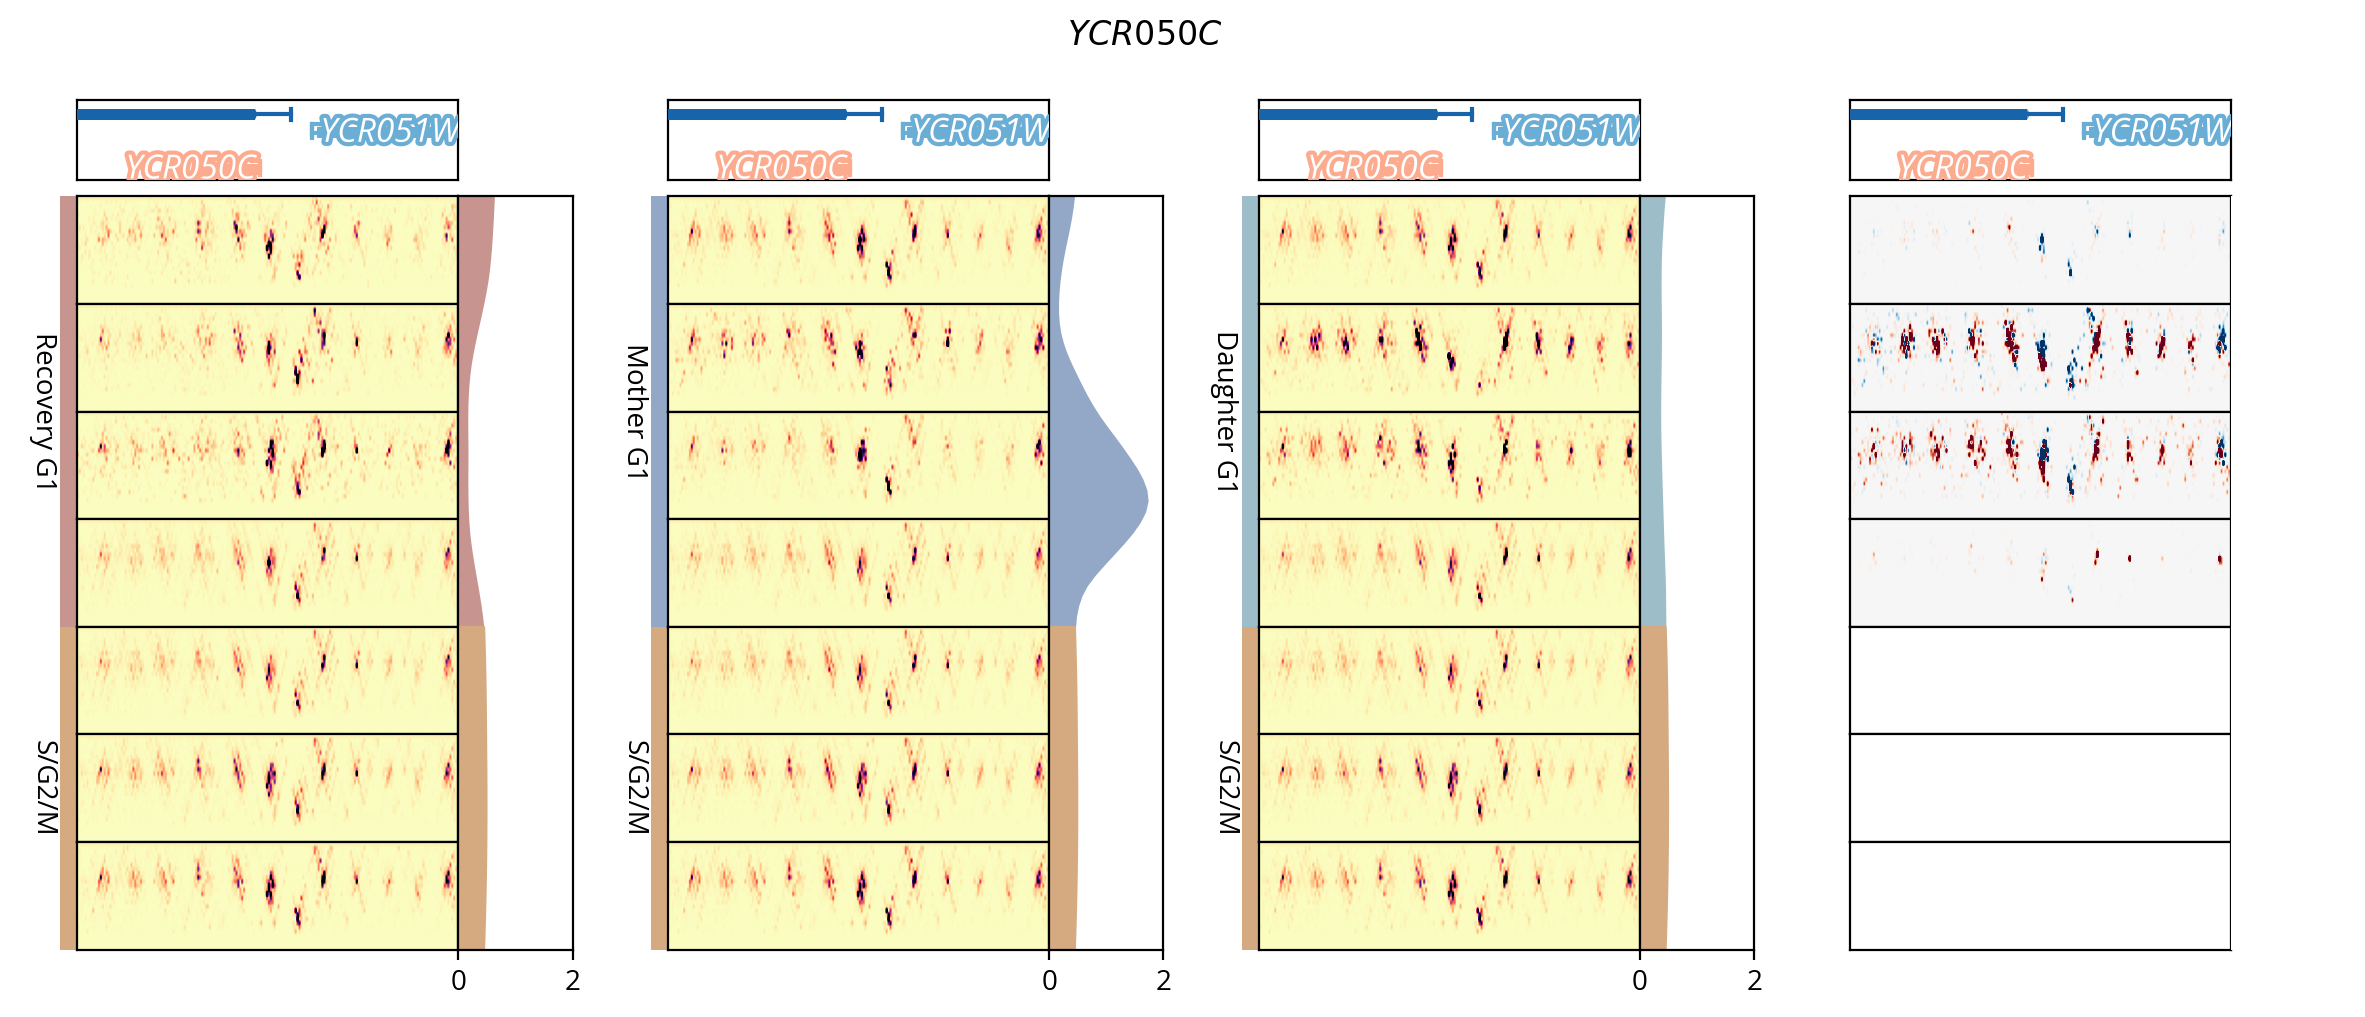

In [952]:
genome_analysis.plot_gene('YCR050C', config1, analysis)

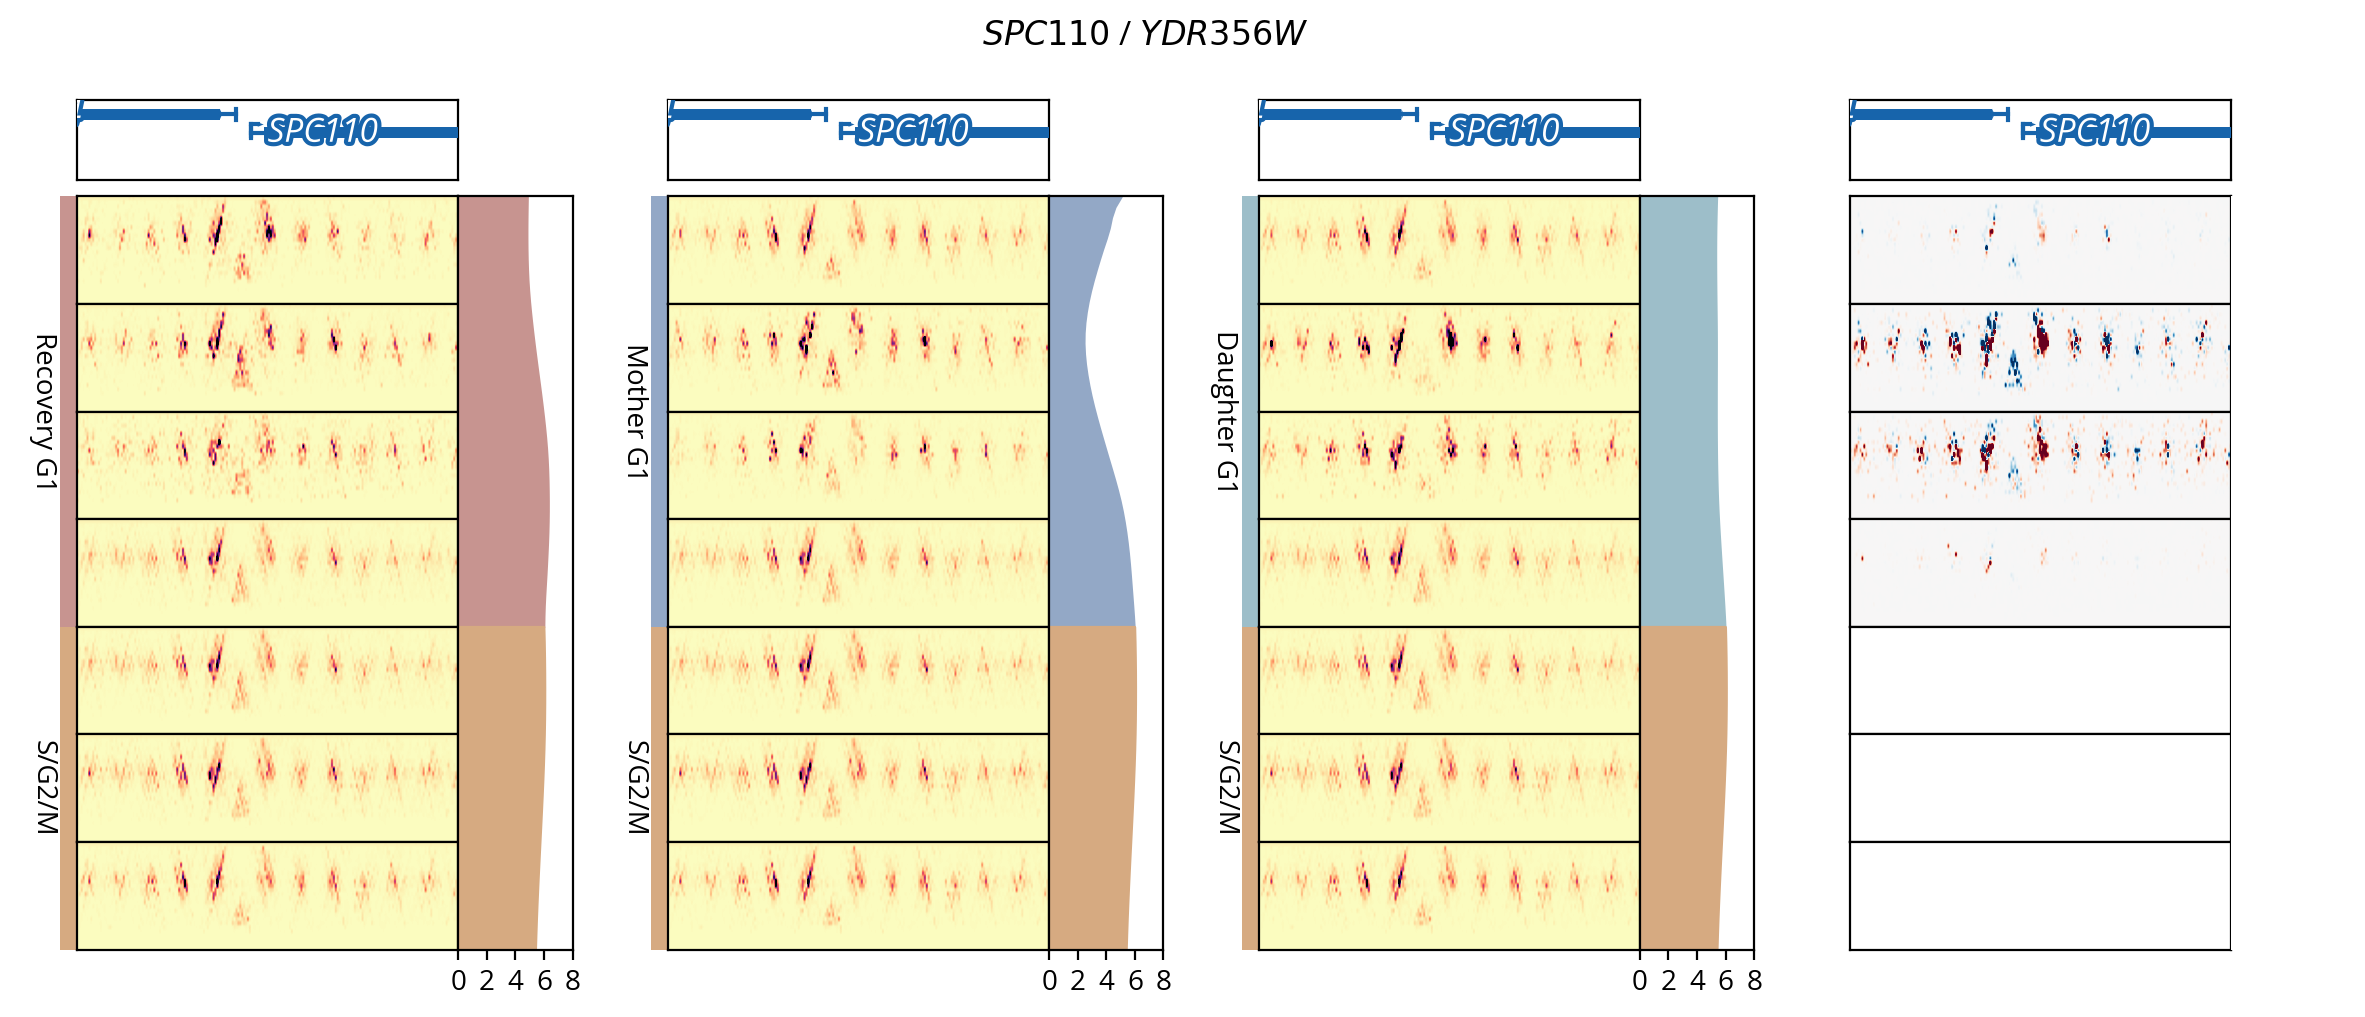

In [953]:
genome_analysis.plot_gene('SPC110', config1, analysis)

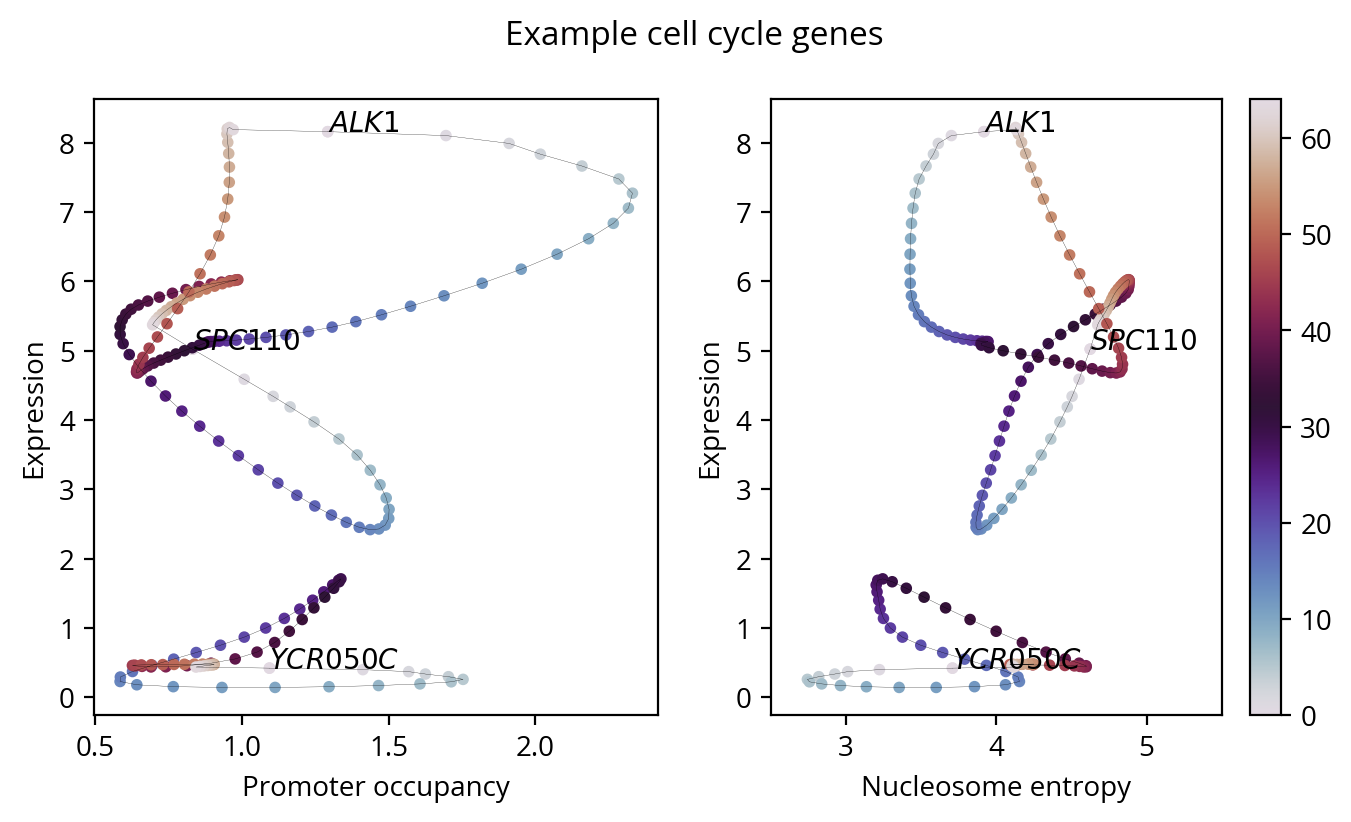

In [954]:
from src.expression_chromatin_analysis_plots import plot_example_gene_cycles
cc_orfs = ['YCR050C', 'YDR356W', 'YGL021W']
plot_example_gene_cycles(cc_orfs, chromatin_analysis, analysis, config1)


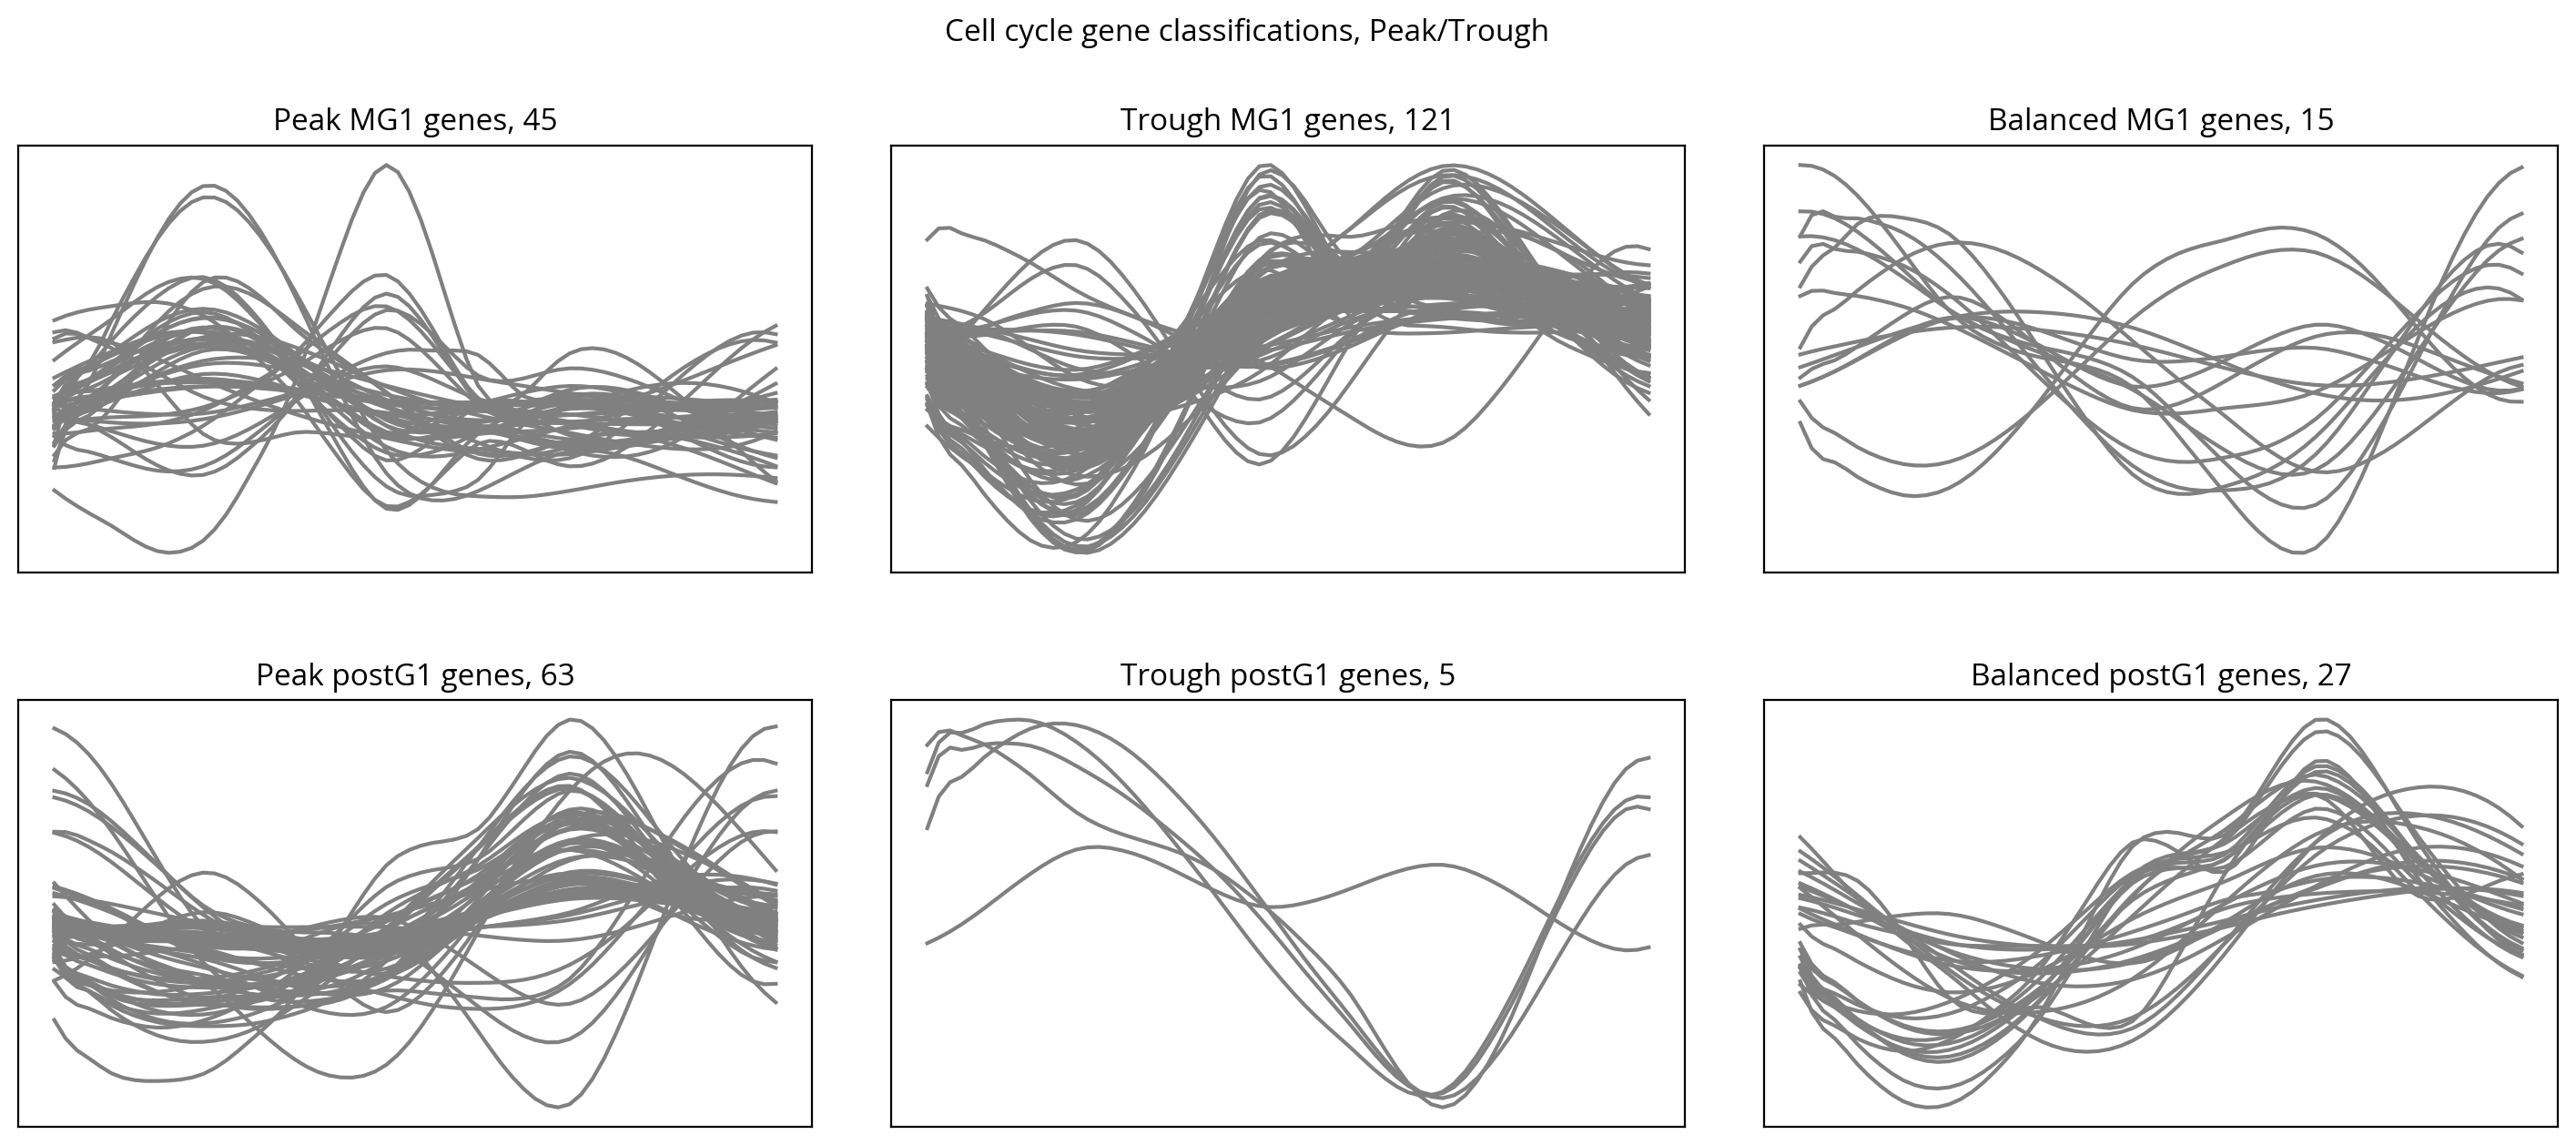

In [1025]:
from pipeline.expression_analysis import plot_skew_cell_cycle_groups

plot_skew_cell_cycle_groups(config1, analysis, expression_combined_polar_data_df)